In [1]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.table as at
import sncosmo
import pickle
import numpy as np
from astropy.table import Table
import h5py

import sys
sys.path.insert(0, '/home/vk9342/GausSN')  # adjust if you cloned elsewhere

# Import the gausSN, kernel, meanfuncs, lensingmodels, and utils packages
import gaussn
from gaussn import gausSN, kernels, meanfuncs, lensingmodels, utils


In [2]:
print(os.path.dirname(gaussn.__file__))

/home/vk9342/GausSN/gaussn


In [3]:
import sncosmo, dynesty, gaussn
print(sncosmo.__version__)
print(dynesty.__version__)
# check if gausSN has a version
print(gausSN.__version__ if hasattr(gausSN, '__version__') else "no version attr")

2.12.0
2.1.4
no version attr


In [4]:
## Load in scarlet2 fluxes
img_index = 50421   #72358   #17462  #96679
version = '_v7'
additional_path = 'different_separations/large_sep/'

if version == '_v6':
    folder = 'roman_both_epoch/'
elif version == '_v7':
    folder = 'roman_off_epoch/'
elif version == '_v8':
    folder = 'roman_no_epoch/'

scarlet_date = '14_04_26'  #used for saving images
oversamplefactor = 1

save_path = f'{additional_path}{img_index}_results/{scarlet_date}/{folder}gaussn/'


sc_times = np.array([0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140])

f = h5py.File('lsst-altsched-1a-lowz.h5','r')
simitems = np.asarray(f['system']['block0_items'][()],dtype=str)
simdataall = f['system']['block0_values'][()]
simdata=simdataall[img_index]
z_source = simdata[simitems == "zs"][0]
if z_source > 0.915:
        z_source = 0.915

# --- Load  Scarlet flux pickle file ---
with open('fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
    flux_data = pickle.load(f)  # shape: [bands, epochs, images]
# --- Load  Scarlet flux errors pickle file ---
with open('fluxes_files/scarlet_deblended_flux_errors/rubin_scarlet_caustics_errors_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
    variance_data = pickle.load(f)  # shape: [bands, epochs, images]


rubin_bands = ['lsstg', 'lsstr', 'lssti']
rubin_params = {'read_noise': 10.0,
        'pixel_scale': 0.2, 
        'ccd_gain': 2.3,
        'exposure_time': {'lsstg': 15.0, 'lsstr': 15.0, 'lssti': 15.0},
        'sky_brightness_mags': {'lsstg': 22.26, 'lsstr': 21.2, 'lssti': 20.48},
        'zero_points_mags': {'lsstg': 28.30, 'lsstr': 28.13, 'lssti': 27.79},
        'num_exposures': {'lsstg': 200, 'lsstr': 460, 'lssti': 460},
        'seeing': {'lsstg':0.77, 'lsstr':0.73, 'lssti':0.71}
    }


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [5]:
## --- Reformat to GaussSN style table --- ###
rows = []
for b_idx, band in enumerate(rubin_bands):                    # loop over bands (g, r, i)
    # if b_idx != 0:
    for epoch_idx, (epoch_fluxes, epoch_variances) in enumerate(zip(flux_data[b_idx], variance_data[b_idx])): # loop over epochs
        # for image_idx, (flux, variance) in enumerate(zip(epoch_fluxes, epoch_variances)):          # loop over image multiplicities
        total_flux = np.sum(epoch_fluxes)
        total_variance = np.sum(epoch_variances)
        rows.append({
                'band': band,
                'image': 'unresolved',     #GausSN uses 1, 2, 3... (and not 0, 1, 2...)
                'time': sc_times[epoch_idx],
                'flux': total_flux,
                'fluxerr': total_variance,
                'zp': rubin_params['zero_points_mags'][band],
                'zpsys': 'AB'
            })
data = Table(rows)
data.sort(['band', 'image', 'time'])

## ---  Convert image index --> string labels so utils.plot_object() doesn’t crash --- ###
# data['image'] = [f"image_{i}" for i in data['image']]

## --- Make all errors constant per band --- ####
median_errs = {}
for band in np.unique(data['band']):
    # mask for this band, and nonzero flux values
    mask = (data['band'] == band) & (data['flux'] != 0)
    # compute median only for those points
    if np.any(mask):
        median_errs[band] = np.median(data['fluxerr'][mask])
    else:
        median_errs[band] = np.nan  # handle case if all fluxes are 0
    print(f"{band}: median fluxerr (excluding flux=0) = {median_errs[band]}")
# Replace all errors with that constant per band
for band in np.unique(data['band']):
    mask = data['band'] == band
    data['fluxerr'][mask] = median_errs[band]


# Normalize fluxes
factor = np.max(data['flux']) - np.min(data['flux'])
data['flux'] = data['flux'] / factor
data['fluxerr'] = data['fluxerr'] / factor

# Normalize times so that the first epoch is 0
data['time'] = data['time'] - np.min(data['time'])

print(data)  



lsstg: median fluxerr (excluding flux=0) = 0.1976287567138801
lssti: median fluxerr (excluding flux=0) = 0.23736775500546214
lsstr: median fluxerr (excluding flux=0) = 0.26816663389938367
 band   image    time     flux            fluxerr          zp  zpsys
----- ---------- ---- ------------ --------------------- ----- -----
lsstg unresolved    0          0.0 0.0005854607560246328  28.3    AB
lsstg unresolved   10 0.0044197296 0.0005854607560246328  28.3    AB
lsstg unresolved   20   0.07768028 0.0005854607560246328  28.3    AB
lsstg unresolved   30   0.29617503 0.0005854607560246328  28.3    AB
lsstg unresolved   36   0.34397614 0.0005854607560246328  28.3    AB
lsstg unresolved   40    0.3328048 0.0005854607560246328  28.3    AB
lsstg unresolved   44    0.2781033 0.0005854607560246328  28.3    AB
lsstg unresolved   48   0.21557601 0.0005854607560246328  28.3    AB
lsstg unresolved   50    0.1838304 0.0005854607560246328  28.3    AB
lsstg unresolved   56   0.11131606 0.0005854607560246

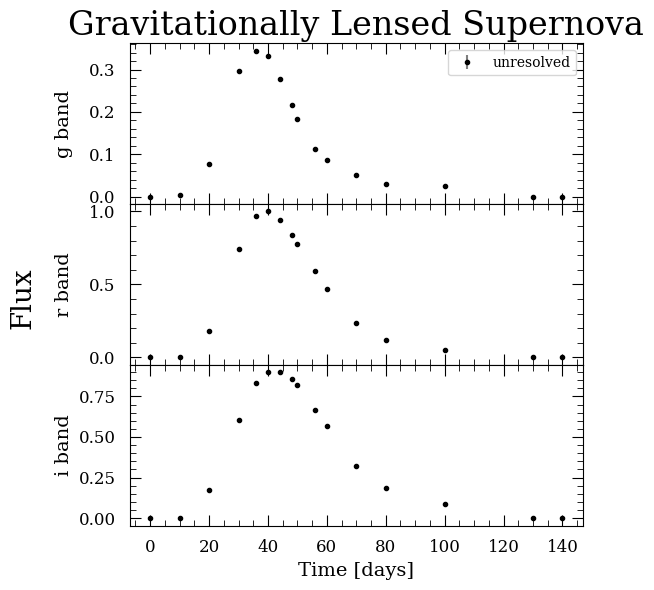

In [6]:
fig, ax = utils.plot_object(data)
plt.show()

## Fitting with the GP model using a zero mean function
### Define a few functions that will be helpful for fitting/plotting

In [7]:
def ptform(u):
    prior = u
    prior[0] = (u[0] * 2)                 # A          --> make prior 0 to 0.2
    prior[1] = (u[1] * 45) + 5            # tau        --> make prior 5 to 50
    prior[2] = (u[2] * 20) + 20           # t0         --> make prior 10 to 70    --> true is 50 unlensed, first imaeg at 30ish tho
    prior[3] = (u[3] * 9900) + 100        # x0/e-9     --> make prior 1e-7 to e-6    --> true is ?? approximately 1??
    prior[4] = (u[4] * 6) - 3             # x1         --> make prior -3 to 3     --> true is 0.1
    prior[5] = (u[5] * 0.7) - 0.3         # c          --> make prior -0.3 to 0.3 --> true is -0.1
    prior[6] = (u[6] * 40) + 1            # delta_1,2  --> make prior 1 to 41     --> true is 19
    prior[7] = (u[7] * 3) + 0.1                 # beta_1,2   --> make prior 0.1 to 2   
    return(prior)

def fit_lensedSN(data, show_plots=False, save_plots = True):

    def _make_mask_unresolved(self, bands, images):
        mask = np.zeros((len(bands), len(bands)))
        for i in range(len(bands)):
            for j in range(len(bands)):
                if bands[i] == bands[j]:
                    mask[i, j] = 1
        return mask

    # Define a GP with a kernel and SALT mean function
    model = sncosmo.Model(source='salt2')
    model.set(z=z_source, t0=50, x0=1, x1=0., c=0.)

    kernel = kernels.ExpSquaredKernel([0.5, 20])
    meanfunc = meanfuncs.sncosmoMean(model=model, fixed=[True, False, False, False, False])
    lensingmodel = lensingmodels.ConstantMagnification([0, 1])
    lensingmodel.make_mask = lambda bands, images: _make_mask_unresolved(lensingmodel, bands, images)
    gp = gausSN.GP(kernel, meanfunc, lensingmodel)
    # gp.n_images = 2
        
    sampler = gp.optimize_parameters(x = data['time'], y = data['flux'], yerr = data['fluxerr'], band = data['band'], image = data['image'],
                                     method='dynesty', ptform=ptform, sampler_kwargs = {'sample': 'rslice'}, n_images = 2)
    
    # If desired, plot the results of the parameter optimization
    if show_plots:
        plt.figure()
        param_names = ['$A$', '$\\tau$', '$t_{0}$', '$x_{0}$', '$x_{1}$', '$c$', '$\\Delta_{1,2}$', '$\\beta_{1,2}$']
        fig, ax = utils.make_corner(sampler.results, param_names)
        fig.show()
        if save_plots:
            fig.savefig(f"{save_path}{img_index}_glimpse_unresolved_fit1{version}.png", bbox_inches='tight')
        fig.show()
        
        fig, ax = utils.make_traceplot(sampler.results, param_names)
        if save_plots:
            fig.savefig(f"{save_path}{img_index}_glipmse_unresolved_fit2{version}.png", bbox_inches='tight')
        fig.show()
    
    return sampler

In [1]:
sampler = fit_lensedSN(data, show_plots=True, save_plots = True)

# Looped version

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


lsstg: median fluxerr (excluding flux=0) = 0.20000242029705378
lssti: median fluxerr (excluding flux=0) = 0.25364900221095266
lsstr: median fluxerr (excluding flux=0) = 0.1876690842543452
 band   image    time     flux           fluxerr          zp  zpsys
----- ---------- ---- ----------- --------------------- ----- -----
lsstg unresolved    0         0.0 0.0014890471763620843  28.3    AB
lsstg unresolved   10 0.018417142 0.0014890471763620843  28.3    AB
lsstg unresolved   20   0.1397395 0.0014890471763620843  28.3    AB
lsstg unresolved   30   0.2504513 0.0014890471763620843  28.3    AB
lsstg unresolved   36  0.21623778 0.0014890471763620843  28.3    AB
lsstg unresolved   40  0.20213592 0.0014890471763620843  28.3    AB
lsstg unresolved   44   0.1551027 0.0014890471763620843  28.3    AB
lsstg unresolved   48  0.11528231 0.0014890471763620843  28.3    AB
lsstg unresolved   50  0.09739853 0.0014890471763620843  28.3    AB
lsstg unresolved   56  0.07288811 0.0014890471763620843  28.3   

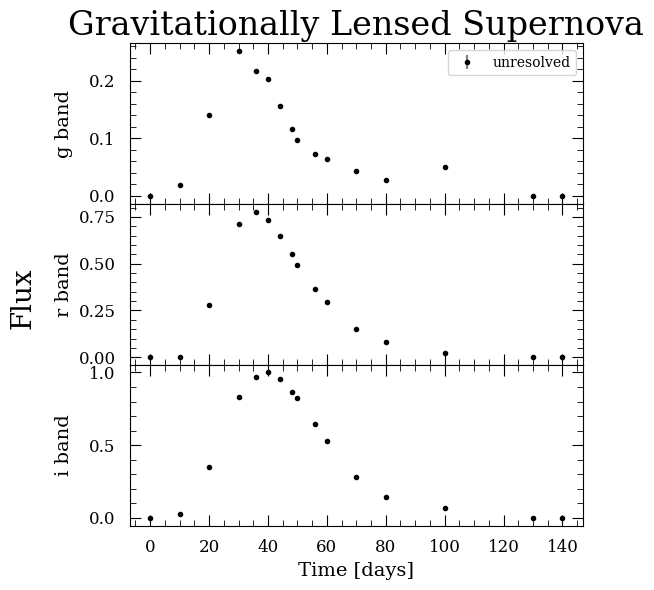

13384it [20:44, 10.75it/s, +500 | bound: 71 | nc: 1 | ncall: 744950 | eff(%):  1.865 | loglstar:   -inf < 109.503 <    inf | logz: 83.327 +/-  0.232 | dlogz:  0.001 >  0.509]


lsstg: median fluxerr (excluding flux=0) = 1.6499981605794747
lssti: median fluxerr (excluding flux=0) = 1.7149891166930793
lsstr: median fluxerr (excluding flux=0) = 1.4740127561755136
 band   image    time     flux          fluxerr          zp  zpsys
----- ---------- ---- ----------- -------------------- ----- -----
lsstg unresolved    0         0.0  0.01266439811784679  28.3    AB
lsstg unresolved   10 0.012011801  0.01266439811784679  28.3    AB
lsstg unresolved   20  0.13344136  0.01266439811784679  28.3    AB
lsstg unresolved   30  0.24791186  0.01266439811784679  28.3    AB
lsstg unresolved   36  0.21057673  0.01266439811784679  28.3    AB
lsstg unresolved   40  0.19823138  0.01266439811784679  28.3    AB
lsstg unresolved   44  0.15016797  0.01266439811784679  28.3    AB
lsstg unresolved   48  0.11078561  0.01266439811784679  28.3    AB
lsstg unresolved   50  0.09299759  0.01266439811784679  28.3    AB
lsstg unresolved   56 0.068178944  0.01266439811784679  28.3    AB
  ...     

<Figure size 640x480 with 0 Axes>

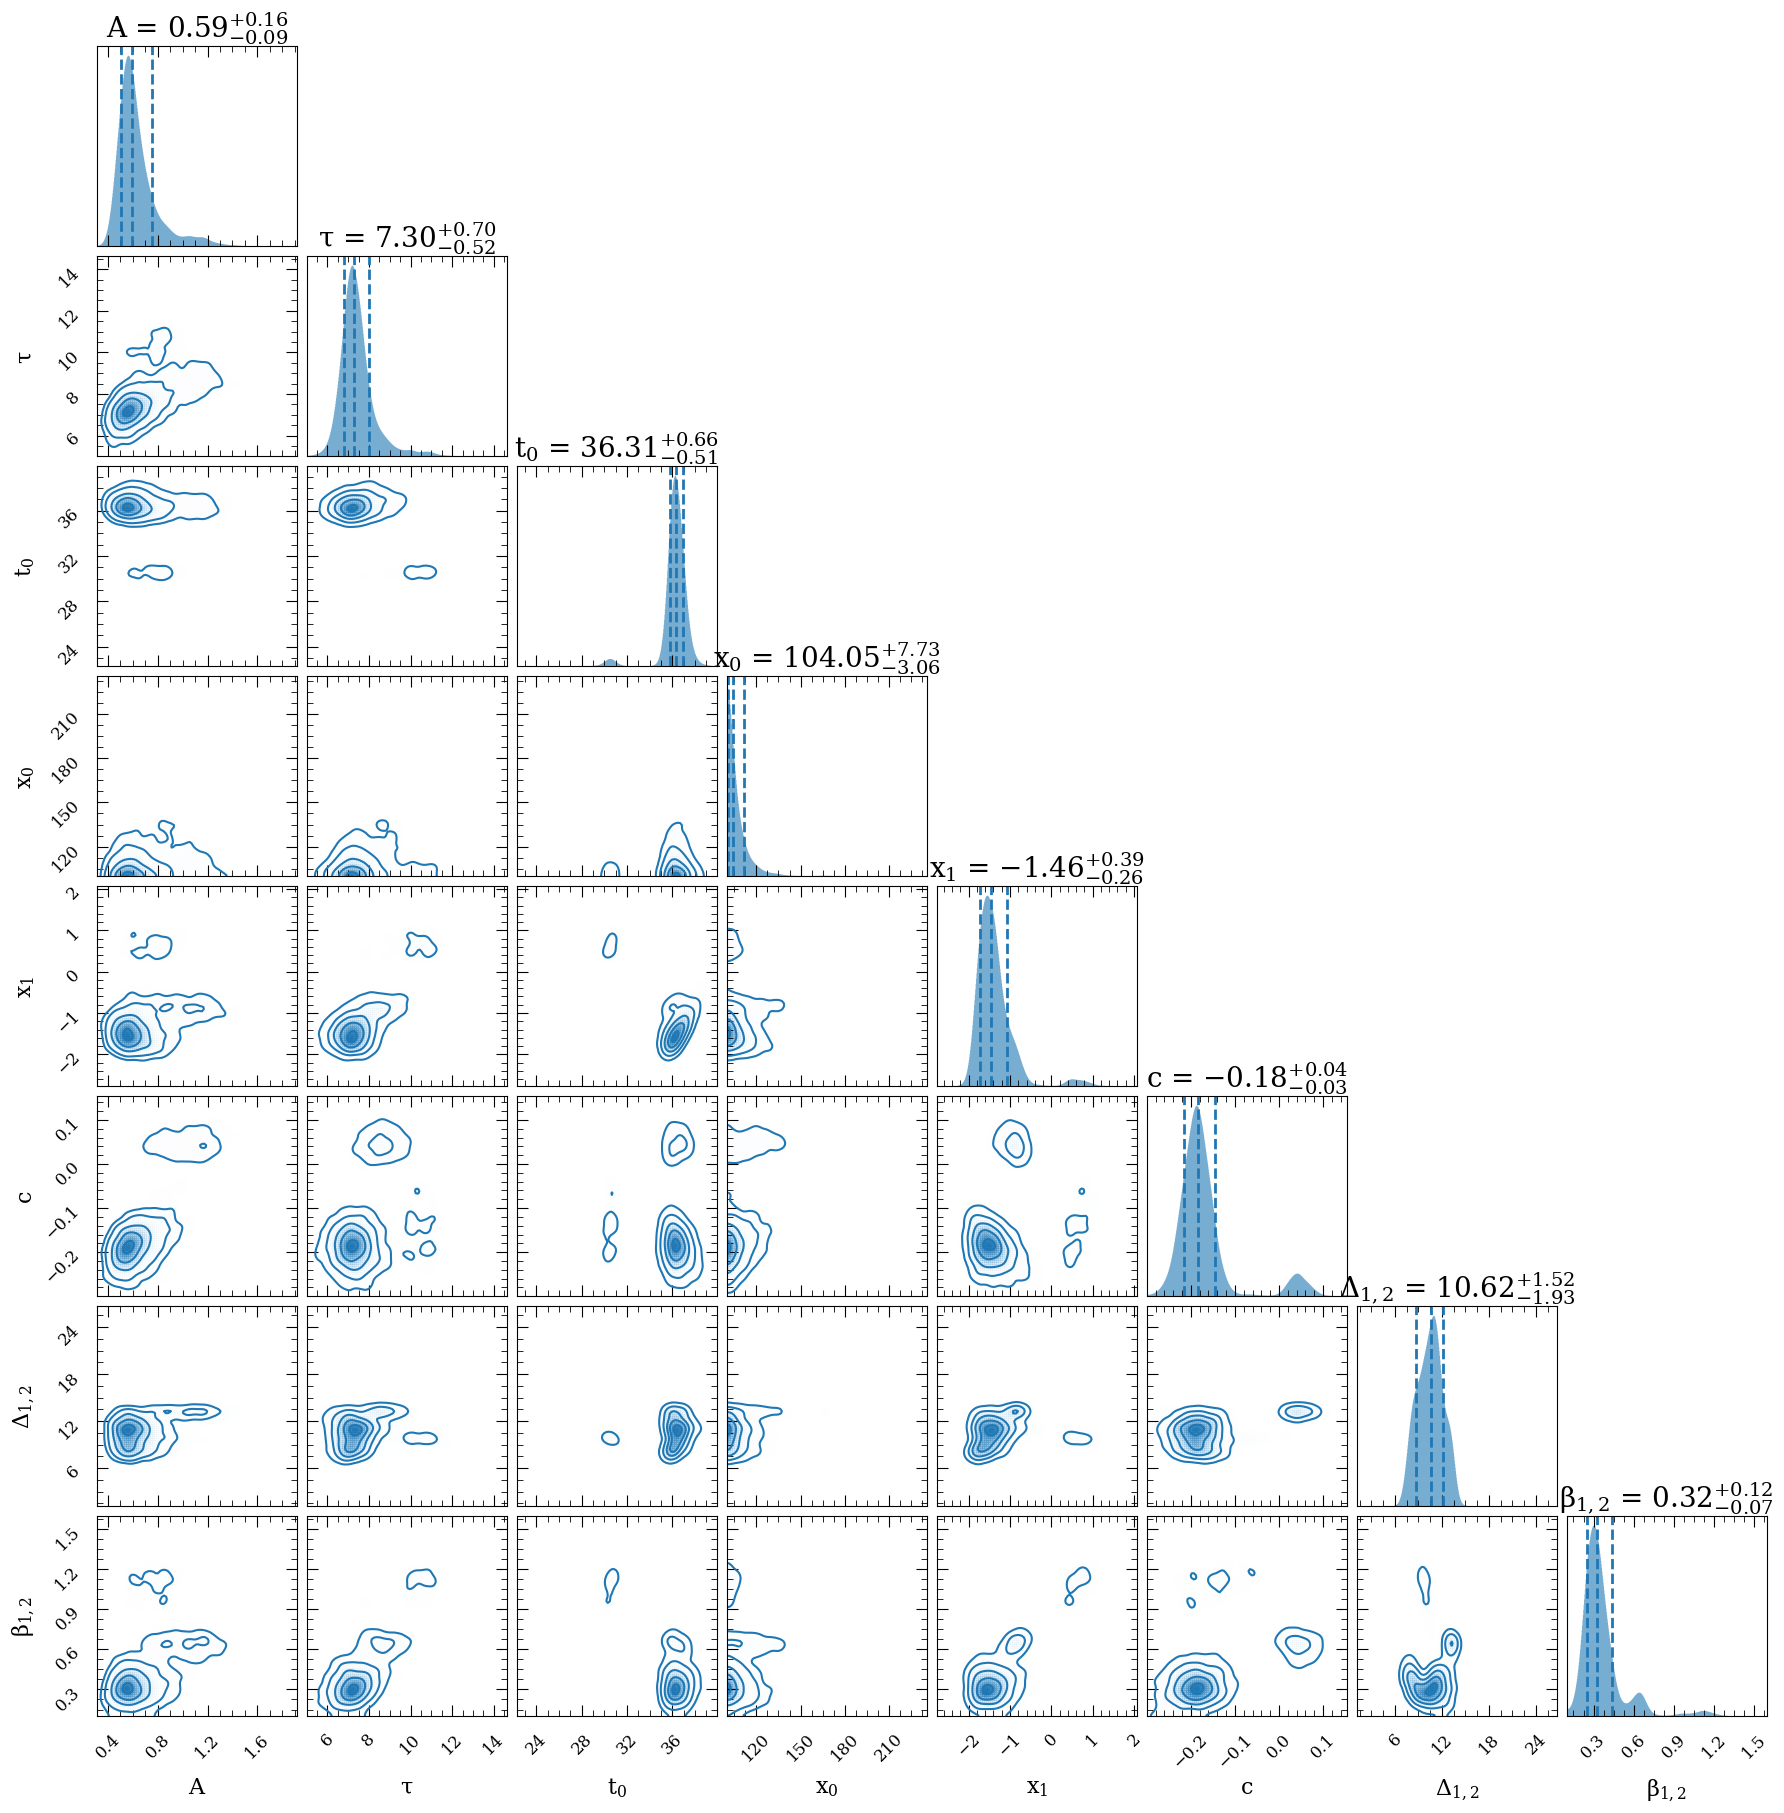

<Figure size 640x480 with 0 Axes>

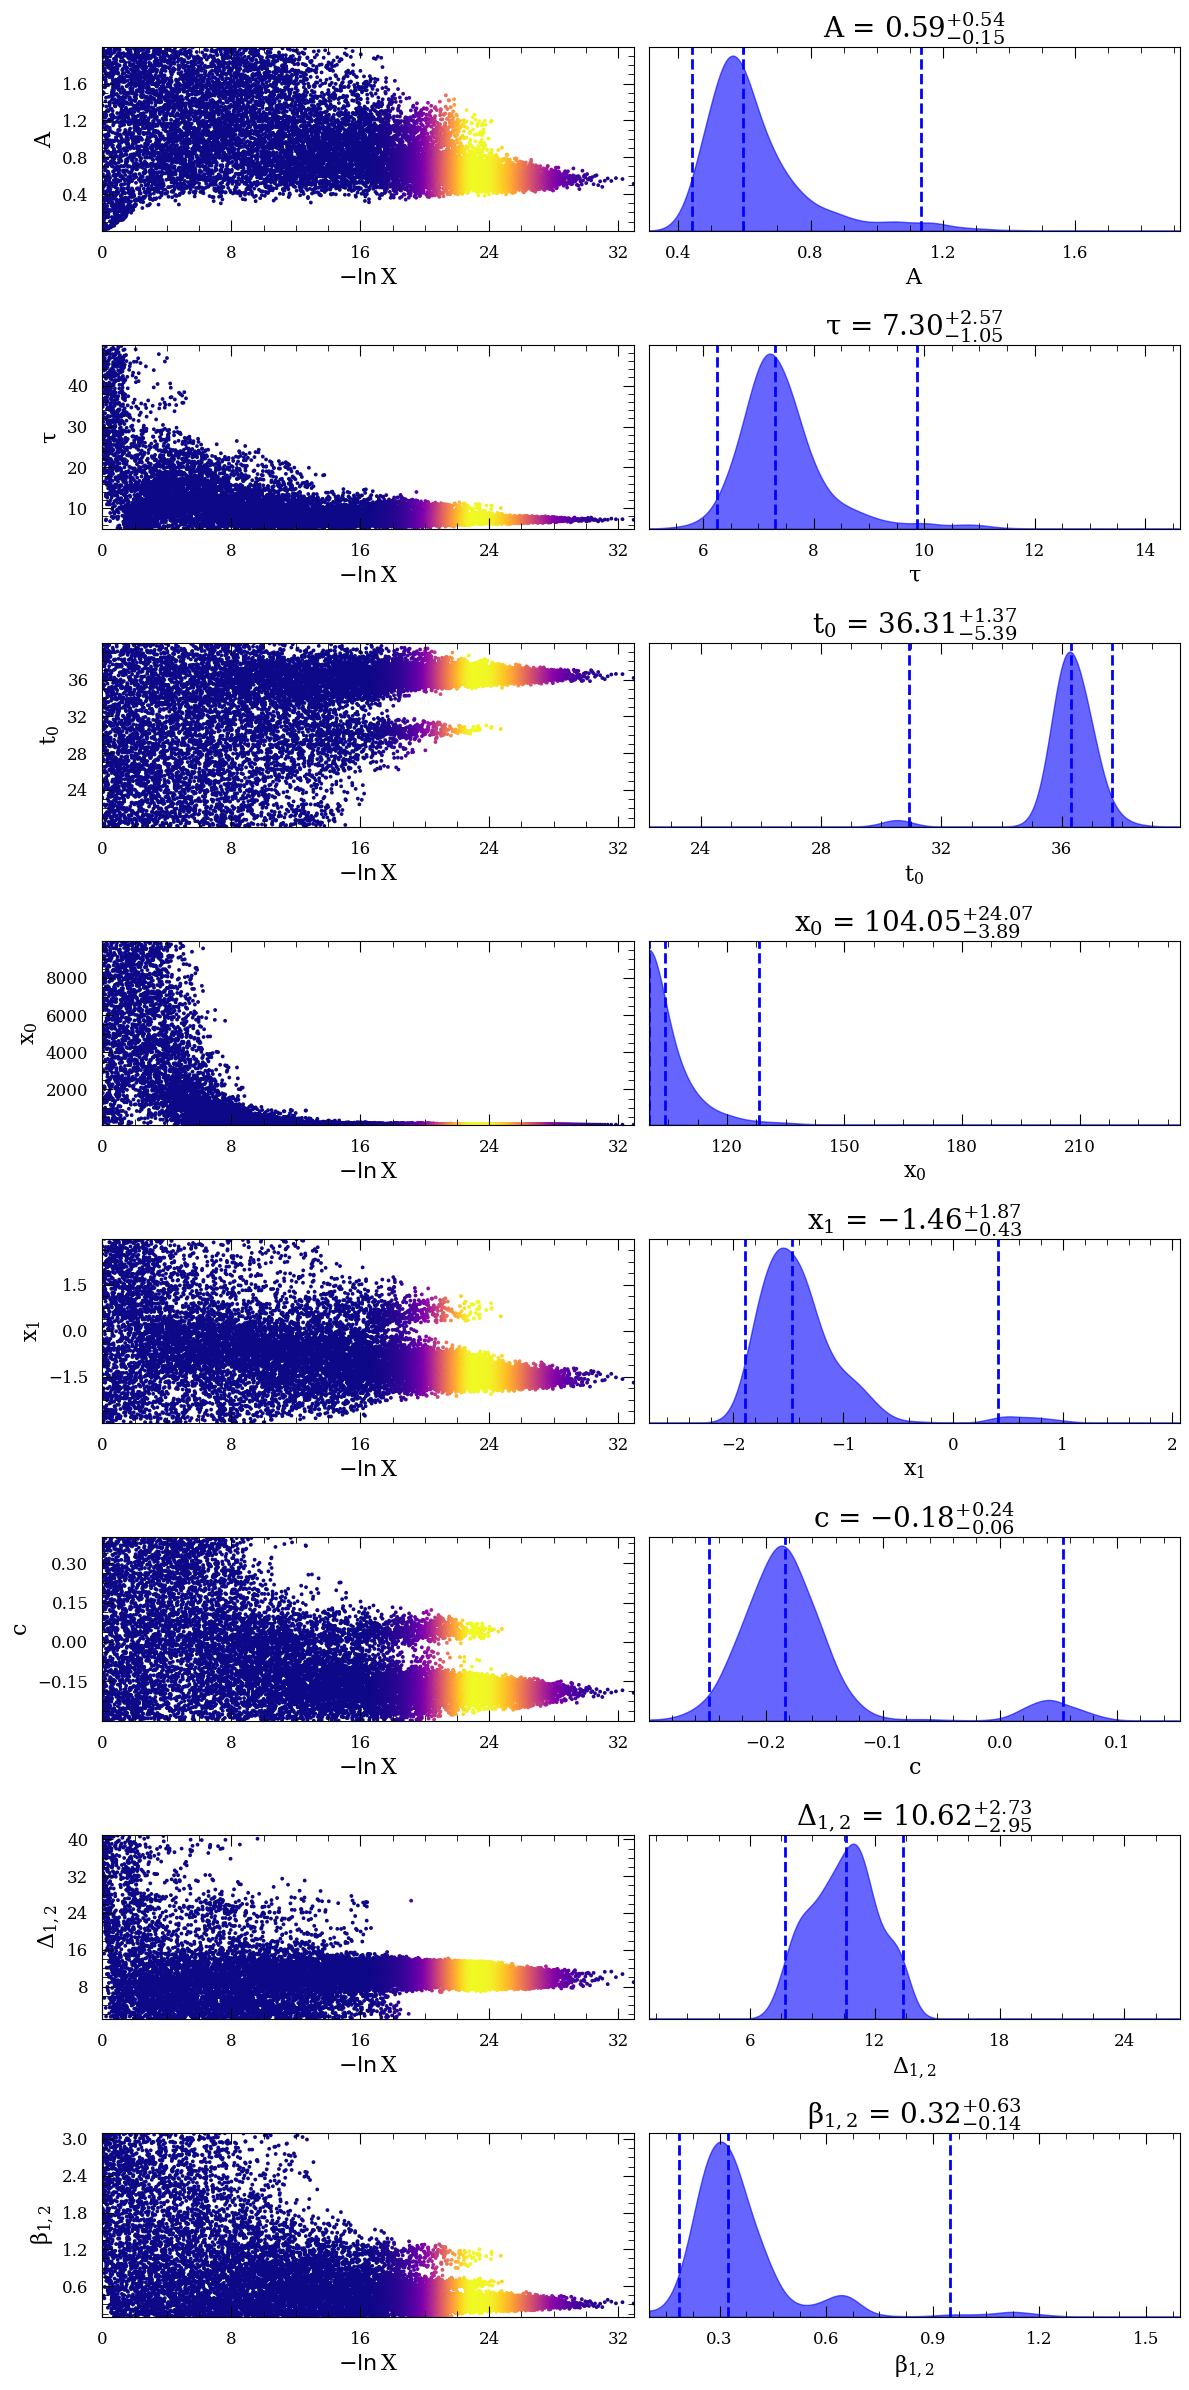

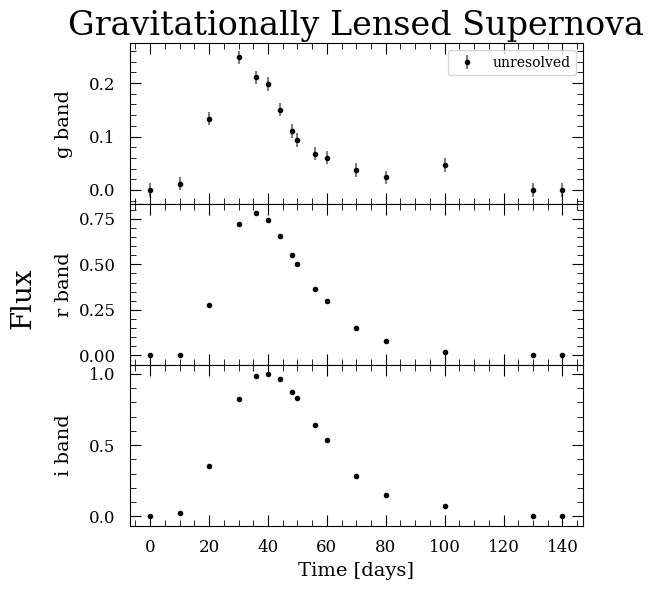

11558it [15:25, 12.49it/s, +500 | bound: 55 | nc: 1 | ncall: 615784 | eff(%):  1.960 | loglstar:   -inf < 129.850 <    inf | logz: 107.296 +/-  0.216 | dlogz:  0.001 >  0.509]


lsstg: median fluxerr (excluding flux=0) = 0.1930666231587999
lssti: median fluxerr (excluding flux=0) = 0.20607539096615157
lsstr: median fluxerr (excluding flux=0) = 0.1853754124855143
 band   image    time     flux            fluxerr          zp  zpsys
----- ---------- ---- ------------ --------------------- ----- -----
lsstg unresolved    0          0.0  0.001693985655512337  28.3    AB
lsstg unresolved   10 4.470688e-07  0.001693985655512337  28.3    AB
lsstg unresolved   20   0.07785638  0.001693985655512337  28.3    AB
lsstg unresolved   30   0.26053286  0.001693985655512337  28.3    AB
lsstg unresolved   36   0.28510407  0.001693985655512337  28.3    AB
lsstg unresolved   40   0.29679444  0.001693985655512337  28.3    AB
lsstg unresolved   44   0.22943966  0.001693985655512337  28.3    AB
lsstg unresolved   48   0.18128106  0.001693985655512337  28.3    AB
lsstg unresolved   50   0.15544629  0.001693985655512337  28.3    AB
lsstg unresolved   56   0.10284359  0.0016939856555123

<Figure size 640x480 with 0 Axes>

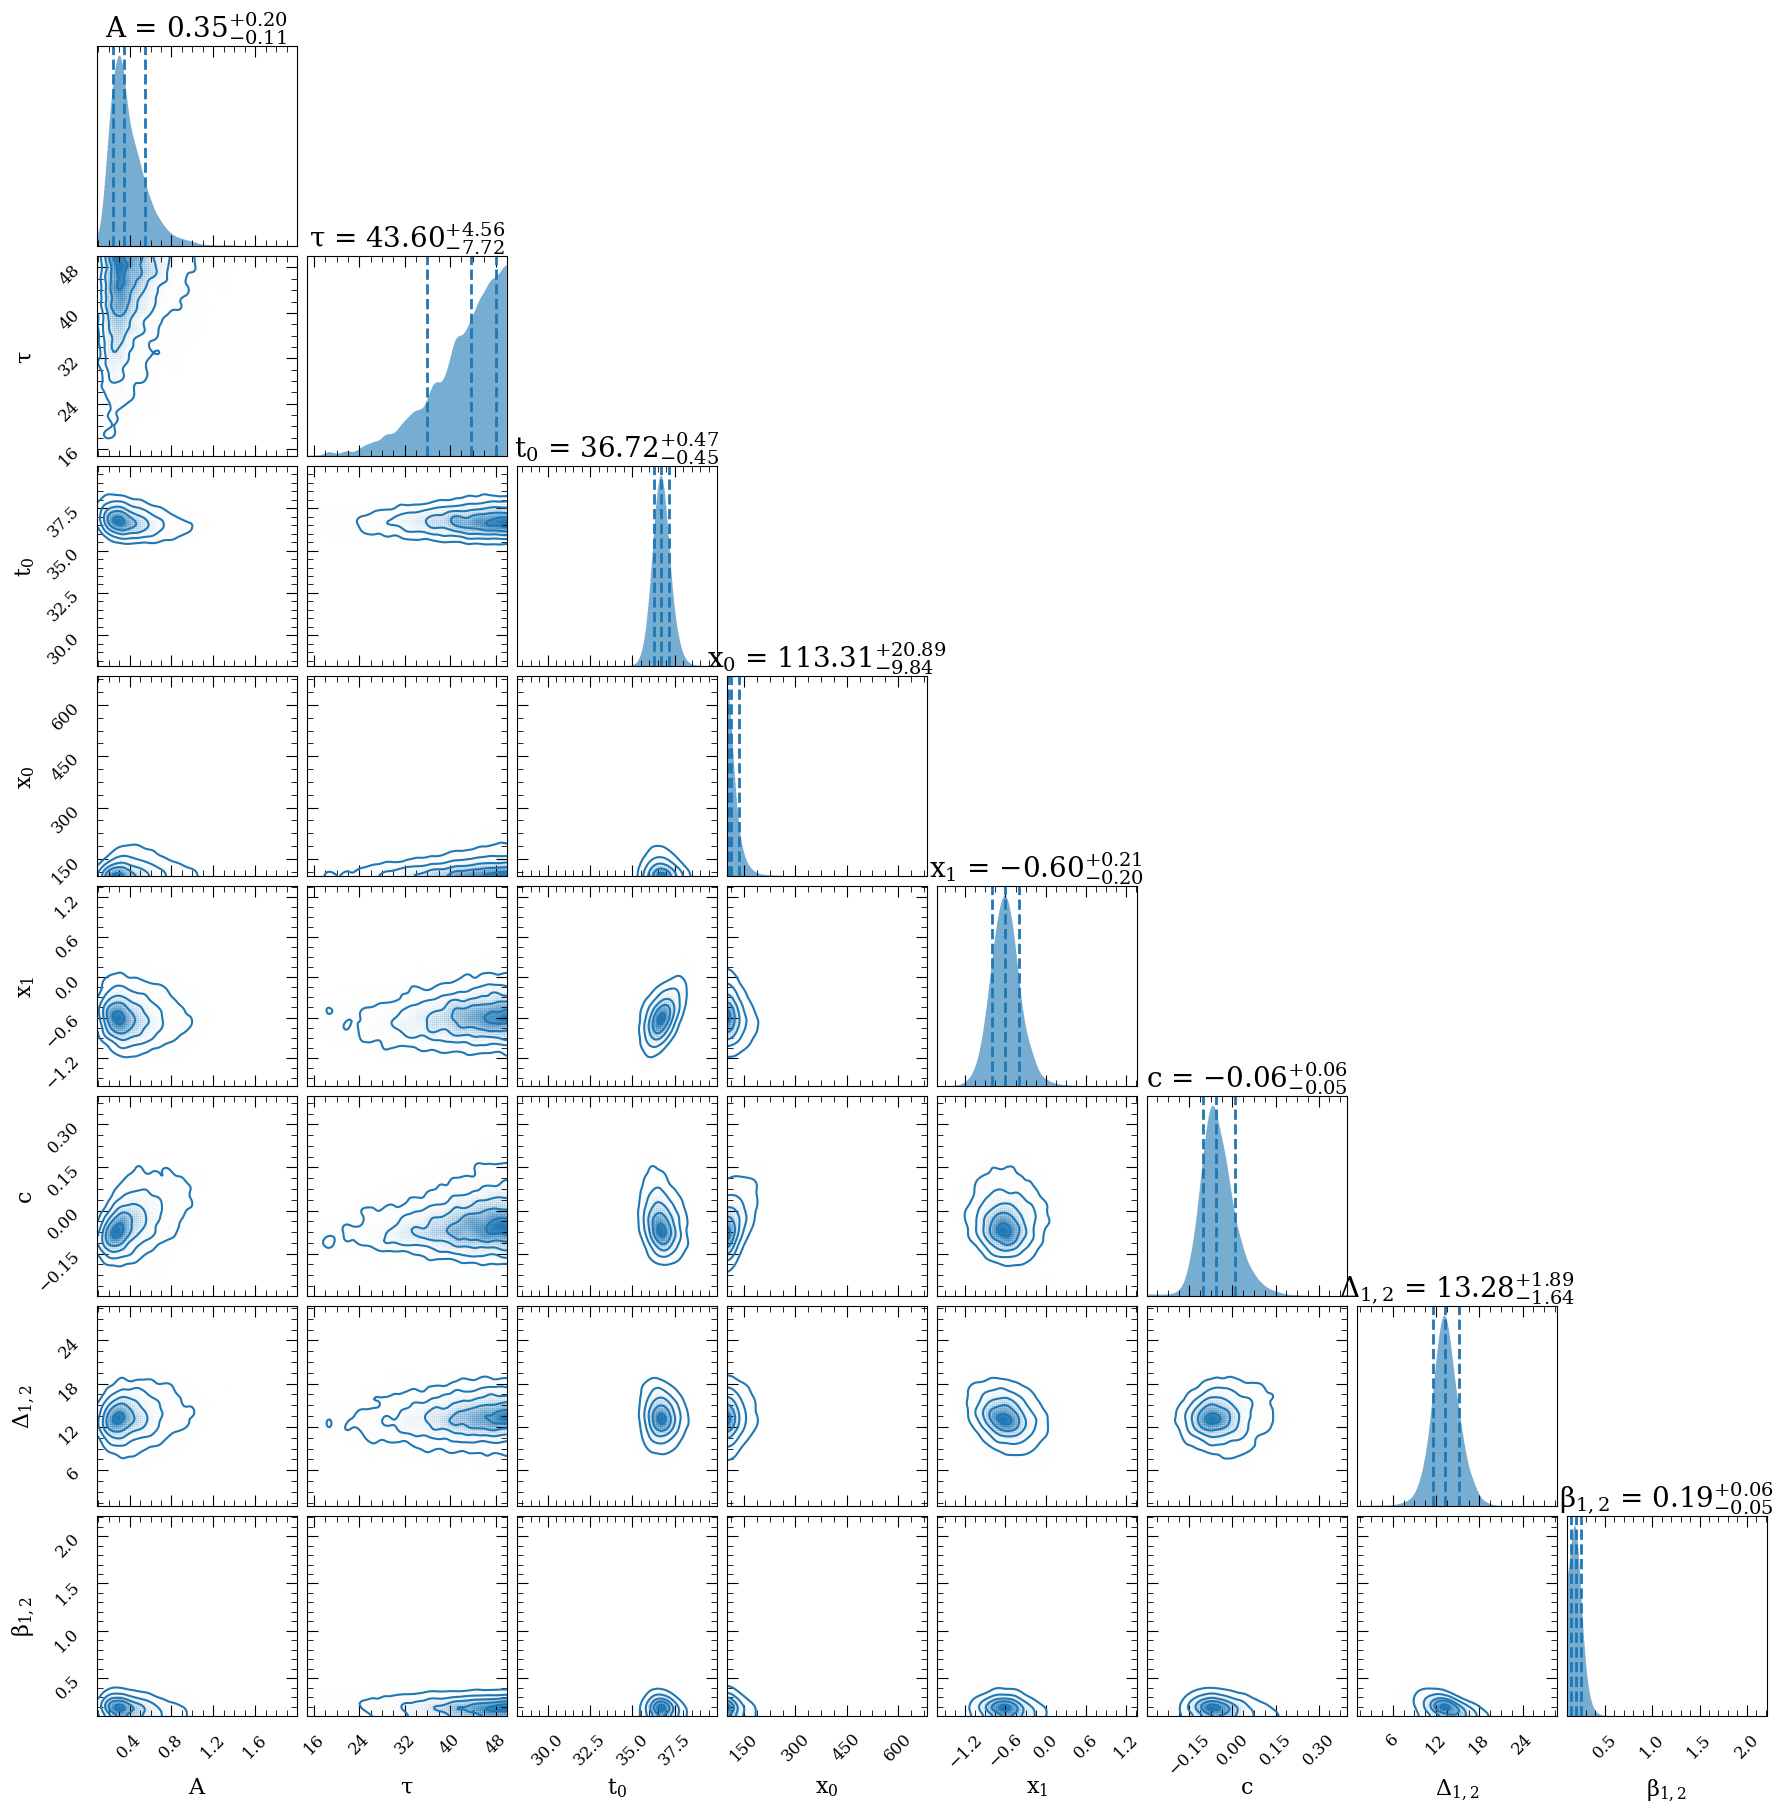

<Figure size 640x480 with 0 Axes>

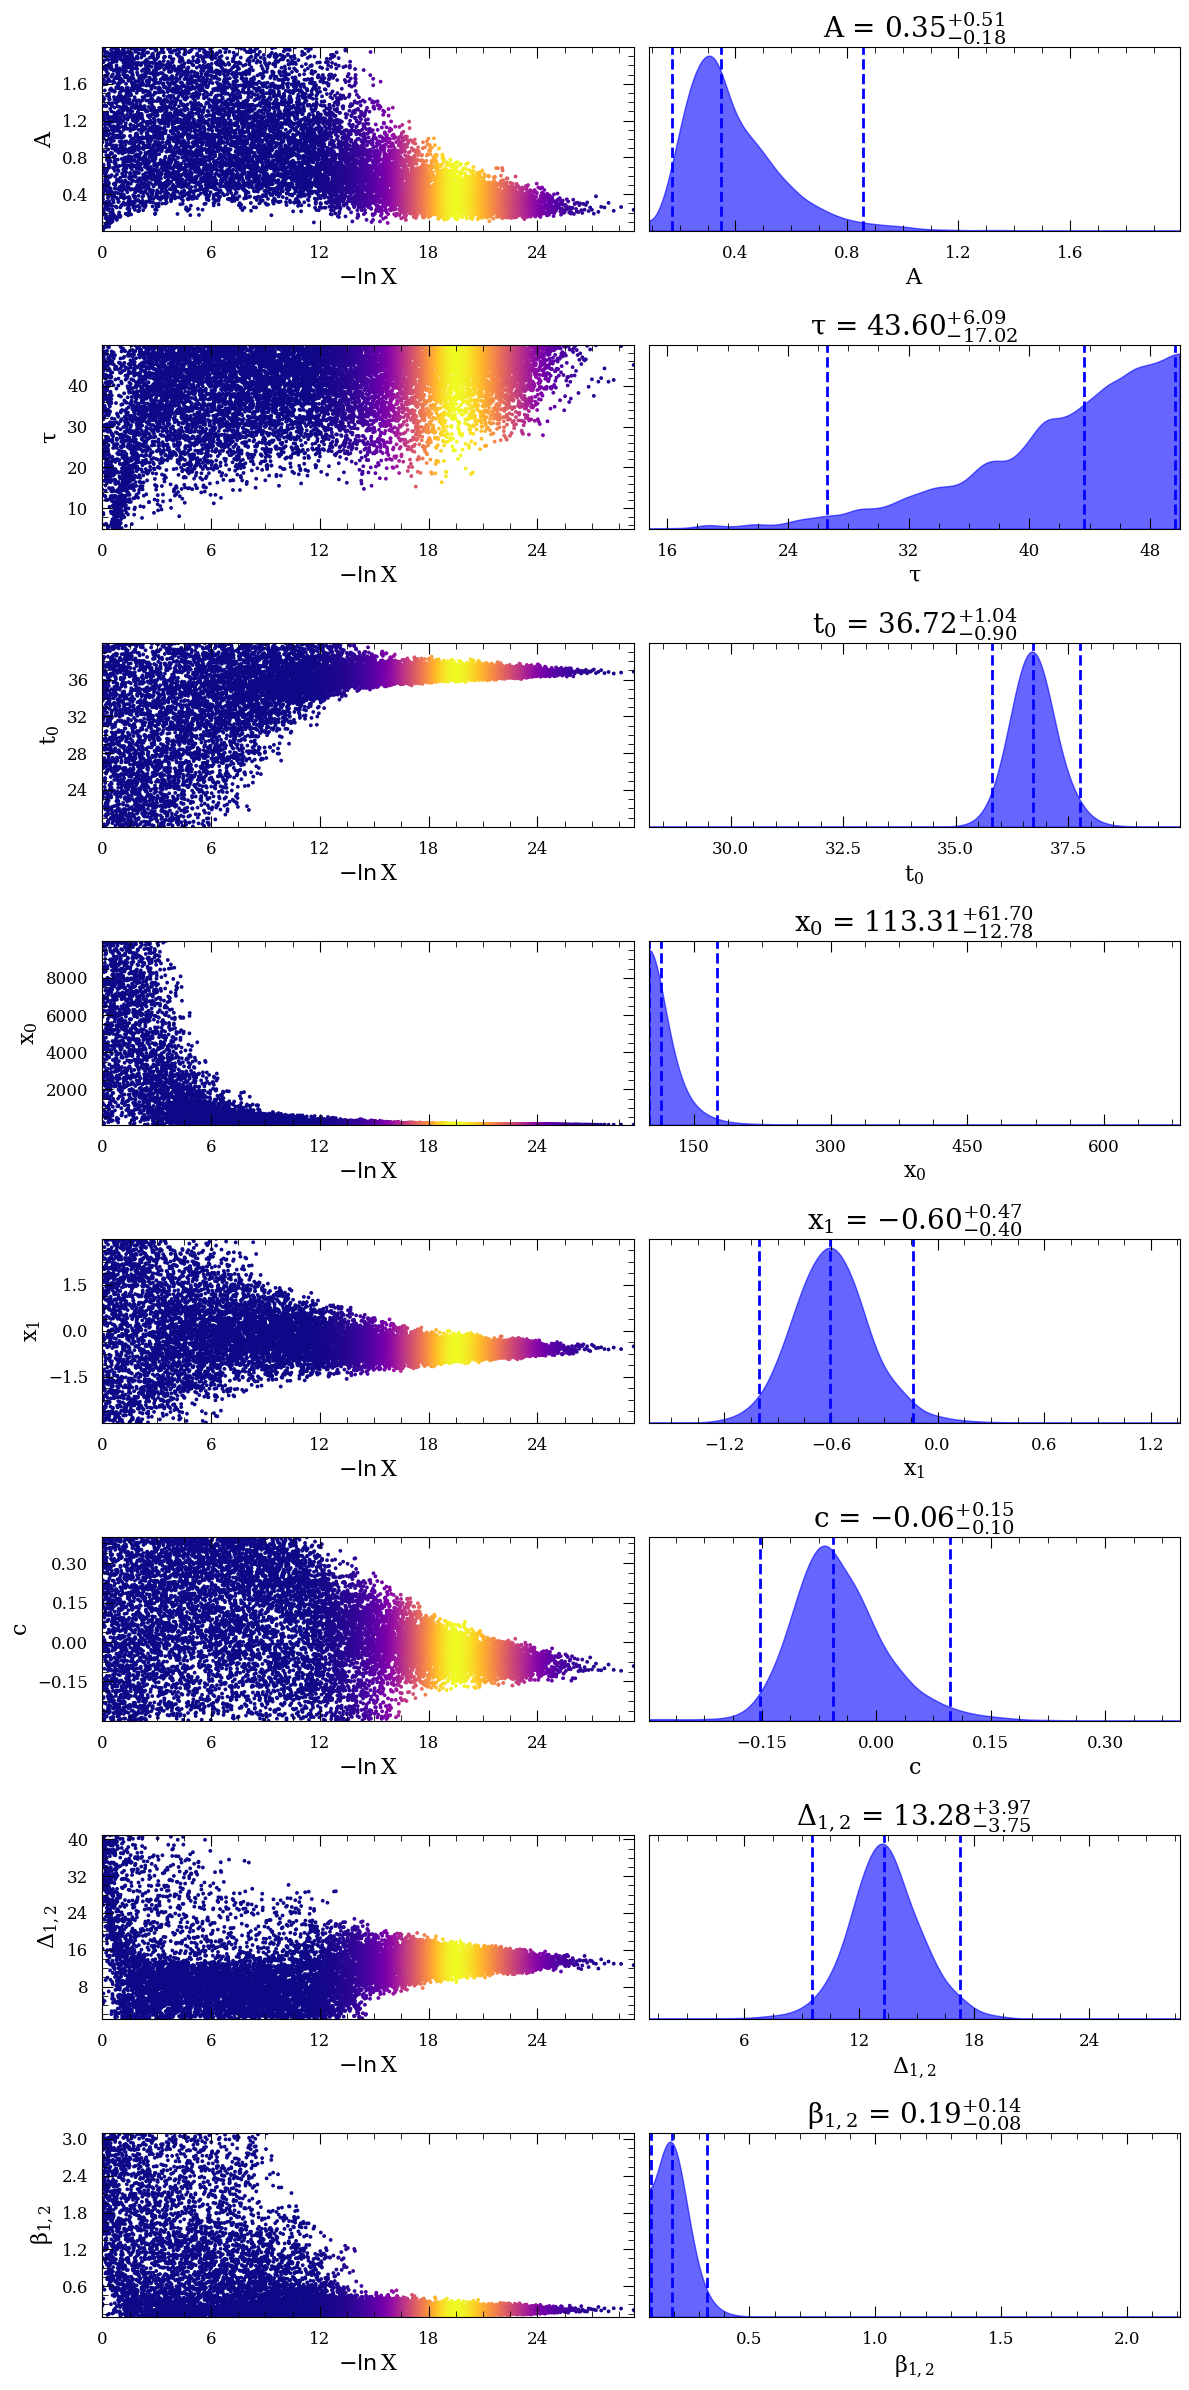

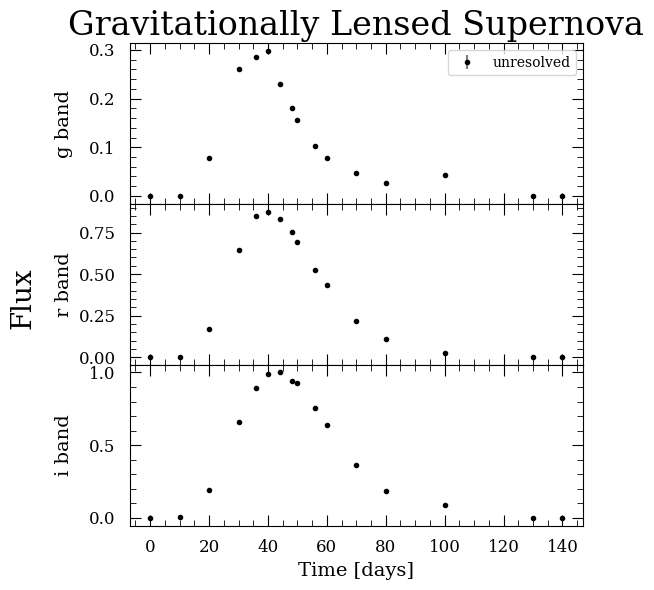

13676it [20:40, 11.03it/s, +500 | bound: 67 | nc: 1 | ncall: 747578 | eff(%):  1.898 | loglstar:   -inf < 112.605 <    inf | logz: 85.836 +/-  0.233 | dlogz:  0.001 >  0.509]


lsstg: median fluxerr (excluding flux=0) = 1.6403250200570227
lssti: median fluxerr (excluding flux=0) = 1.904420543845628
lsstr: median fluxerr (excluding flux=0) = 1.5968796073870837
 band   image    time     flux           fluxerr          zp  zpsys
----- ---------- ---- ------------ -------------------- ----- -----
lsstg unresolved    0          0.0  0.01465225677630069  28.3    AB
lsstg unresolved   10 0.0012322661  0.01465225677630069  28.3    AB
lsstg unresolved   20   0.08807893  0.01465225677630069  28.3    AB
lsstg unresolved   30   0.27597144  0.01465225677630069  28.3    AB
lsstg unresolved   36   0.29905996  0.01465225677630069  28.3    AB
lsstg unresolved   40   0.30689934  0.01465225677630069  28.3    AB
lsstg unresolved   44   0.23878258  0.01465225677630069  28.3    AB
lsstg unresolved   48   0.19084765  0.01465225677630069  28.3    AB
lsstg unresolved   50   0.16431491  0.01465225677630069  28.3    AB
lsstg unresolved   56   0.11062552  0.01465225677630069  28.3    AB

<Figure size 640x480 with 0 Axes>

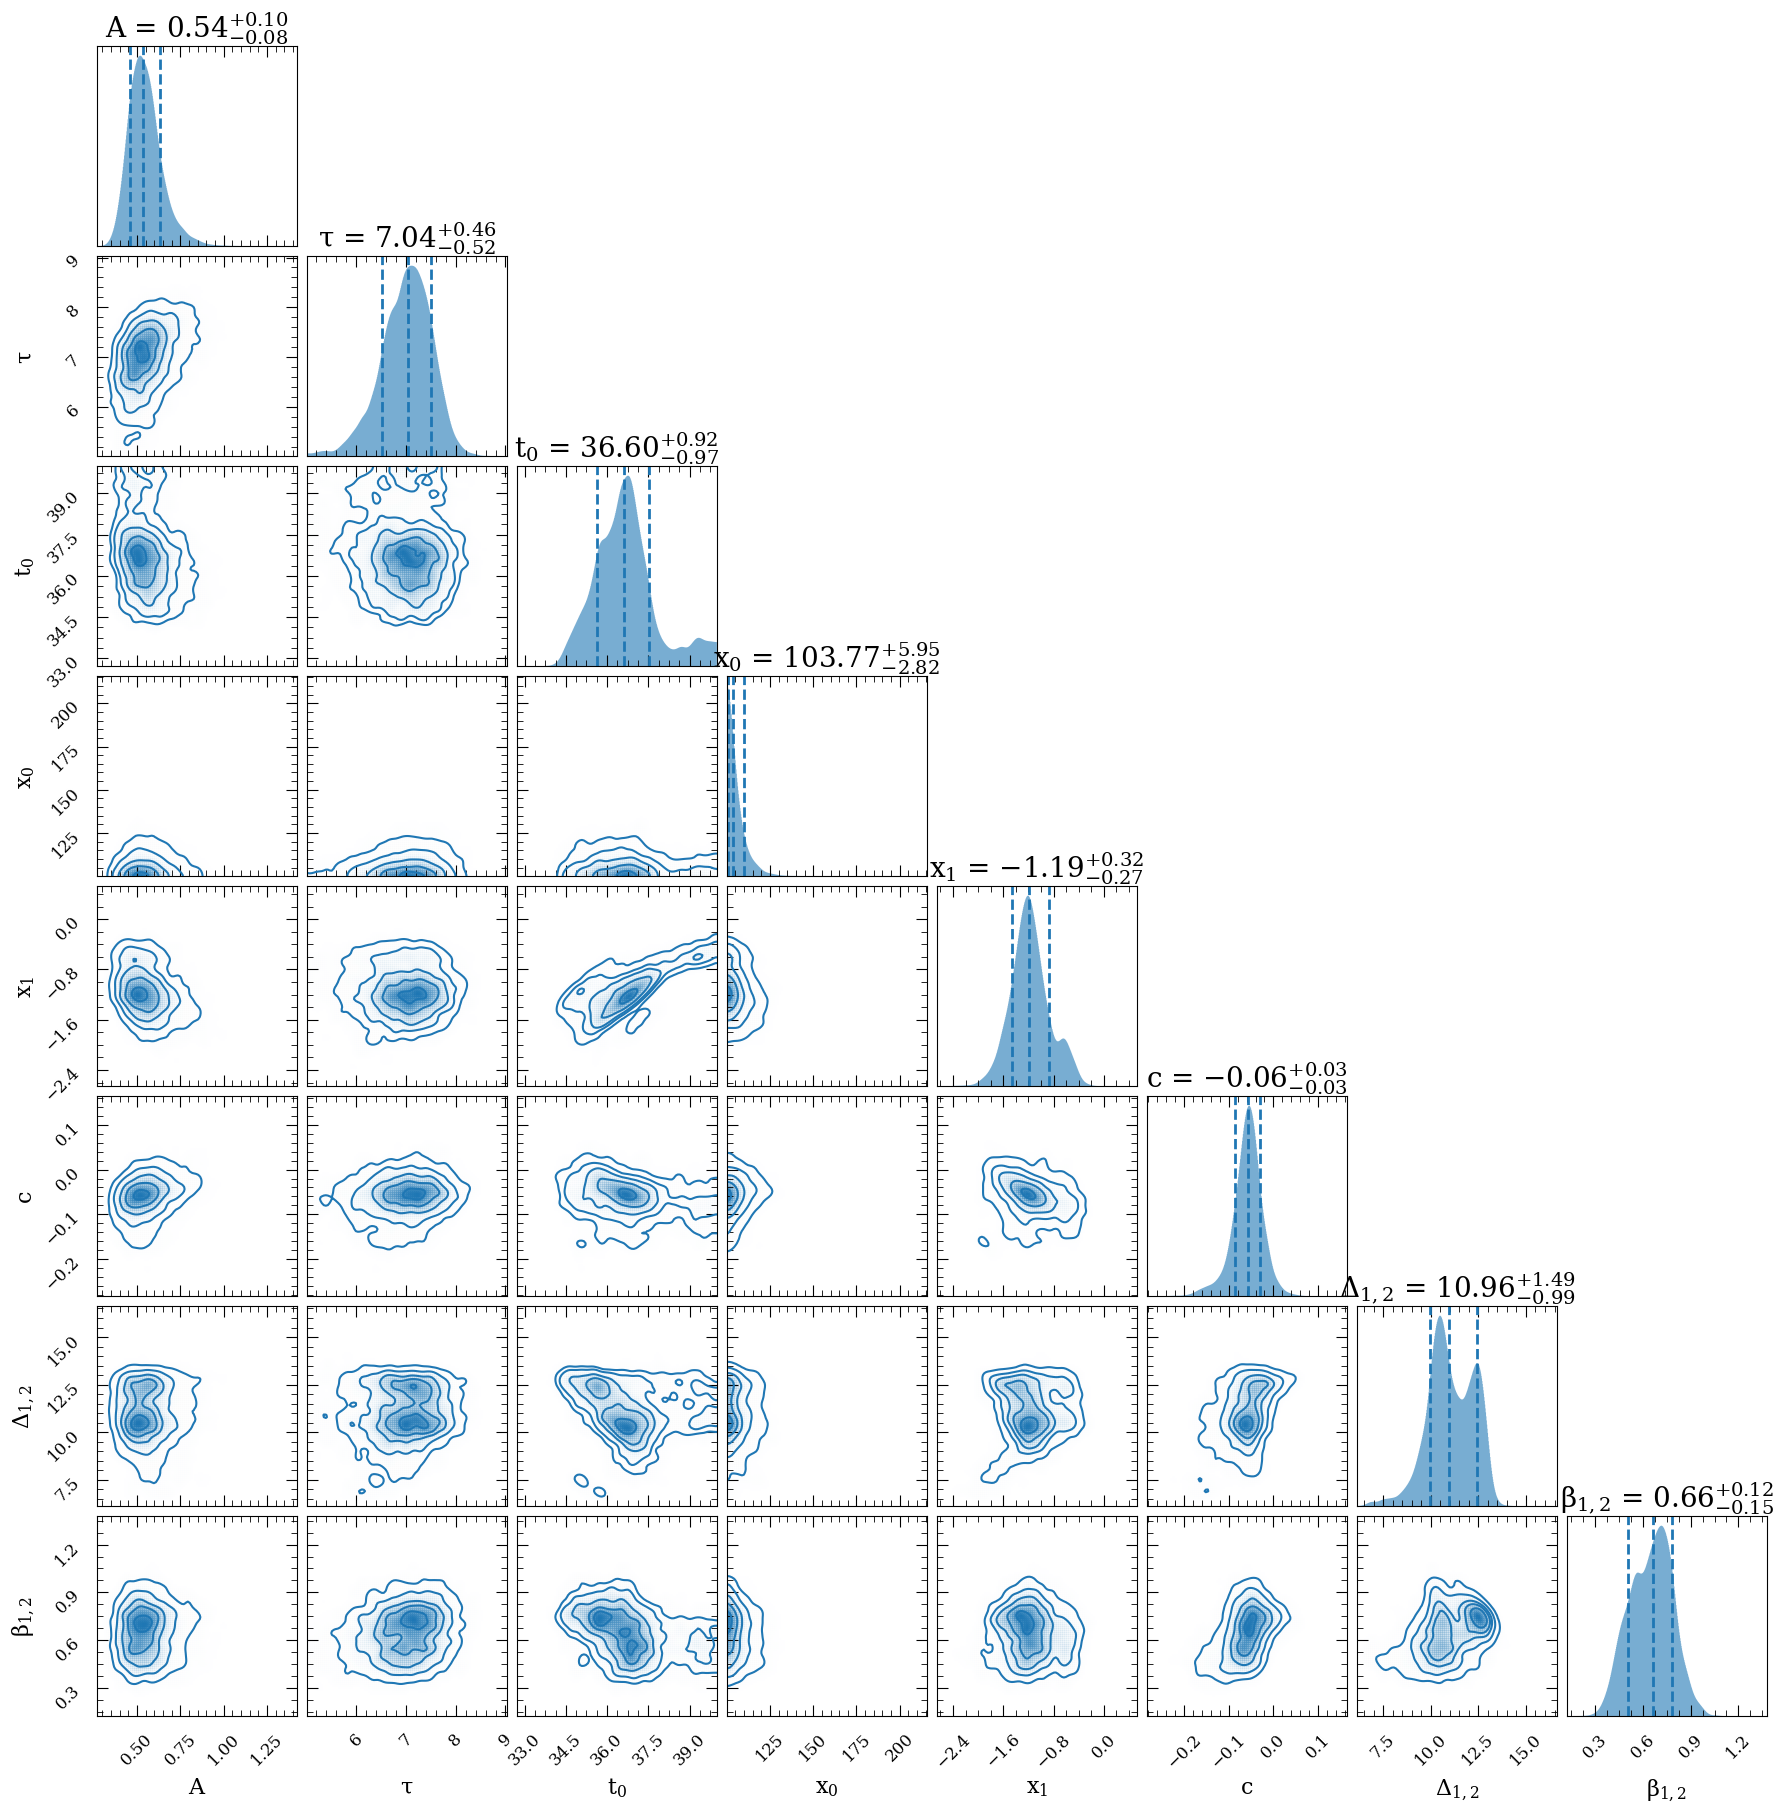

<Figure size 640x480 with 0 Axes>

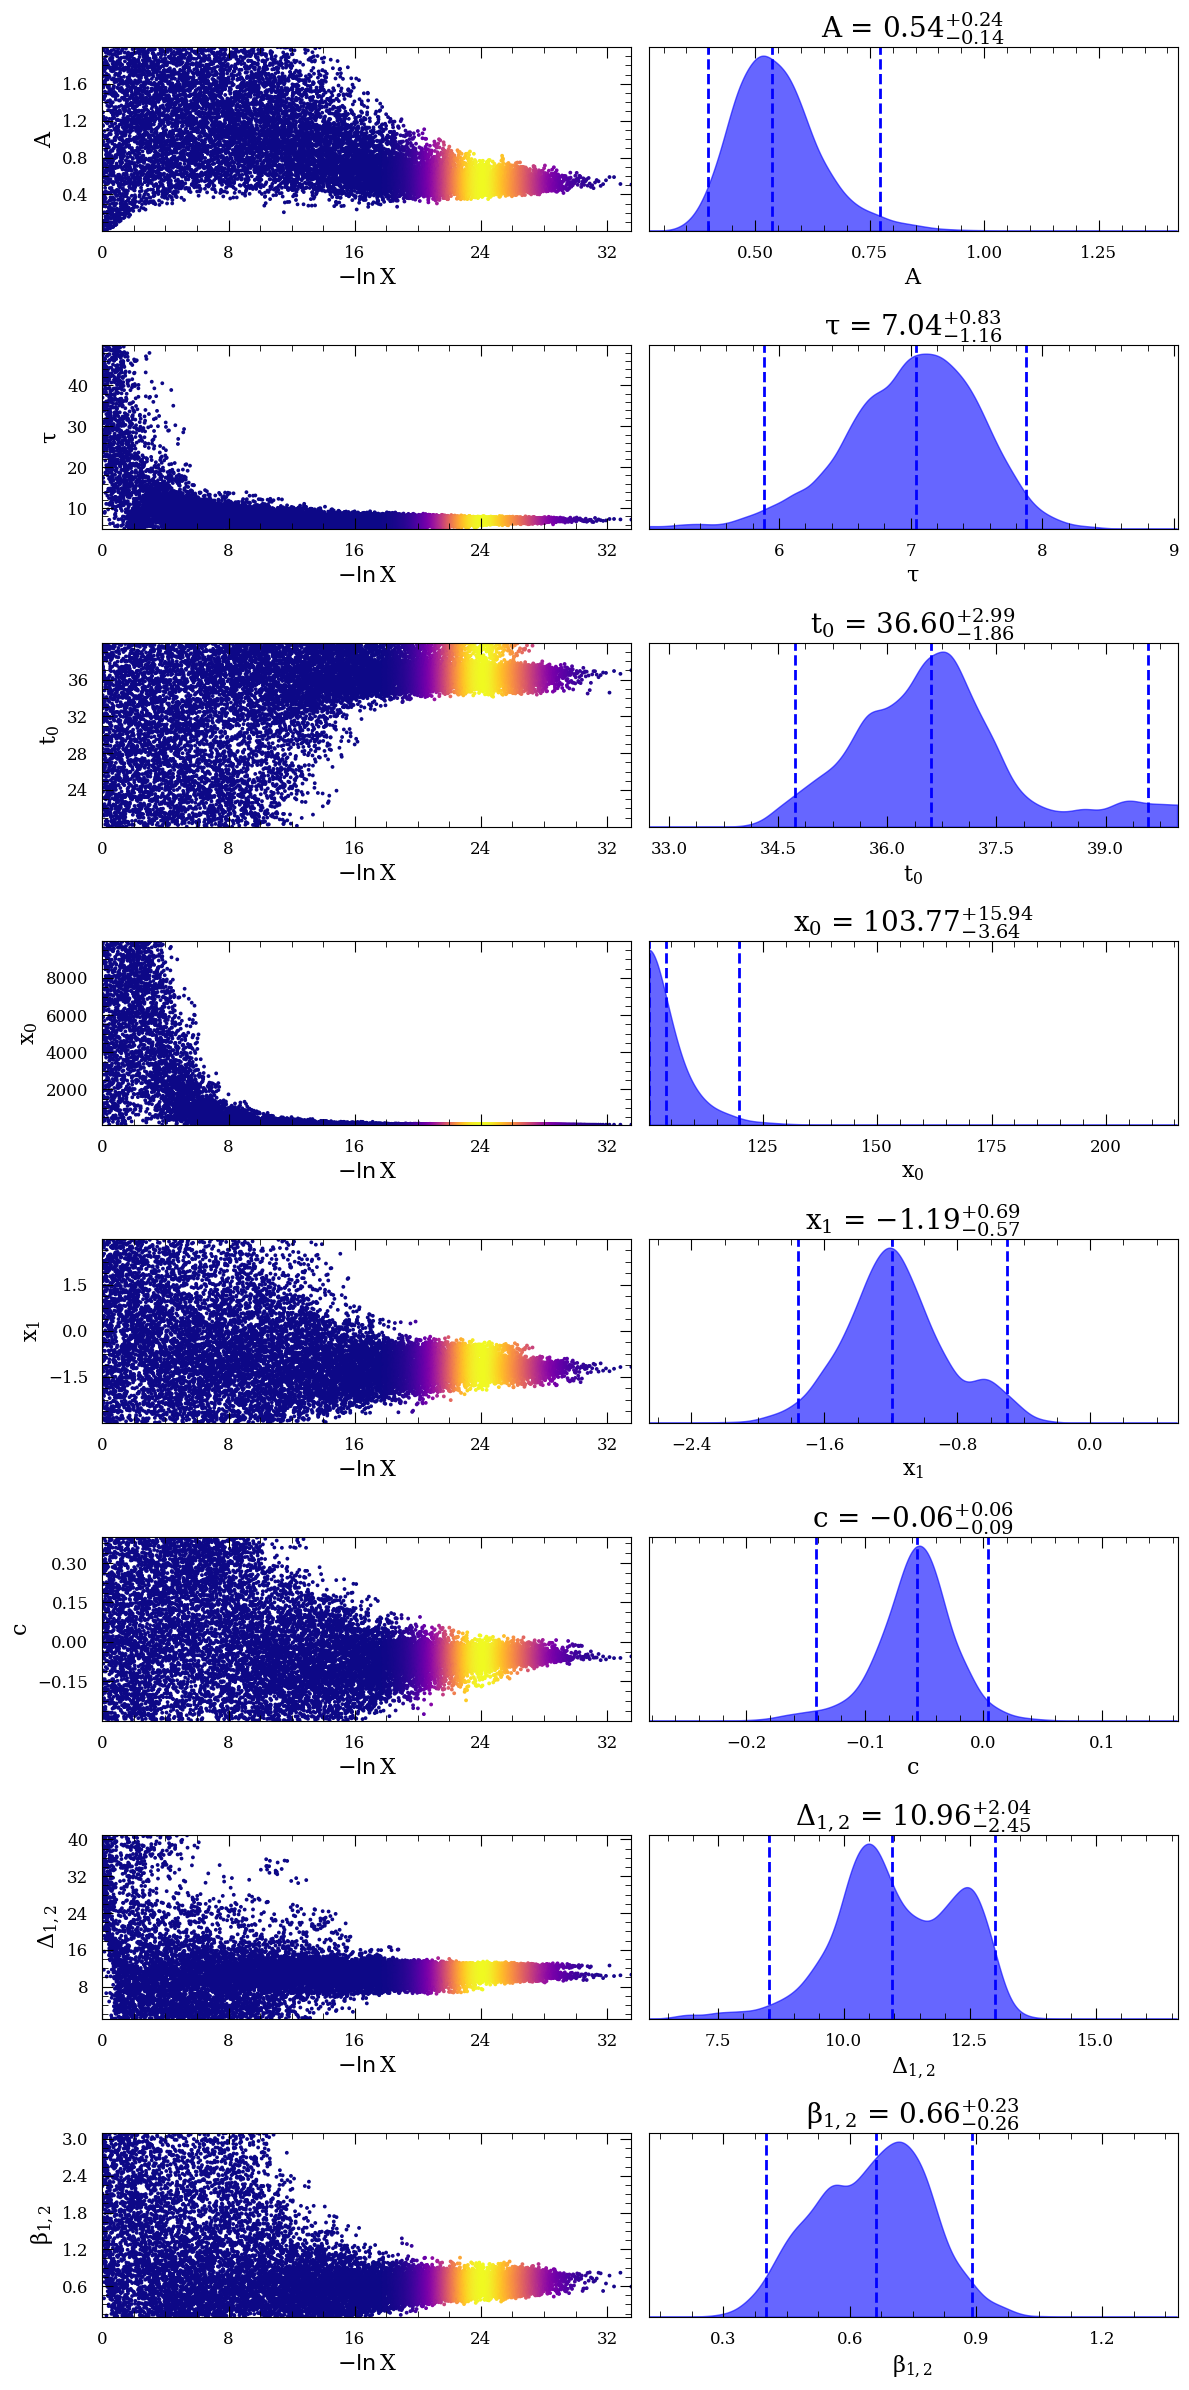

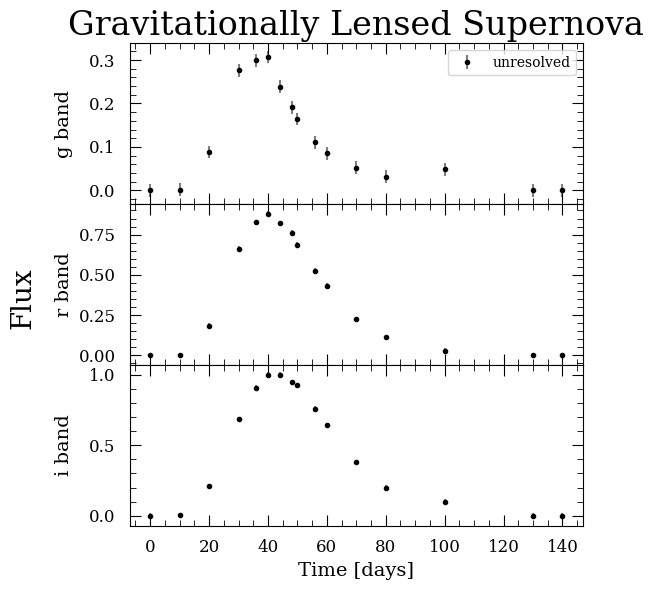

11523it [15:23, 12.48it/s, +500 | bound: 55 | nc: 1 | ncall: 610173 | eff(%):  1.972 | loglstar:   -inf < 126.131 <    inf | logz: 103.656 +/-  0.216 | dlogz:  0.001 >  0.509]


<Figure size 640x480 with 0 Axes>

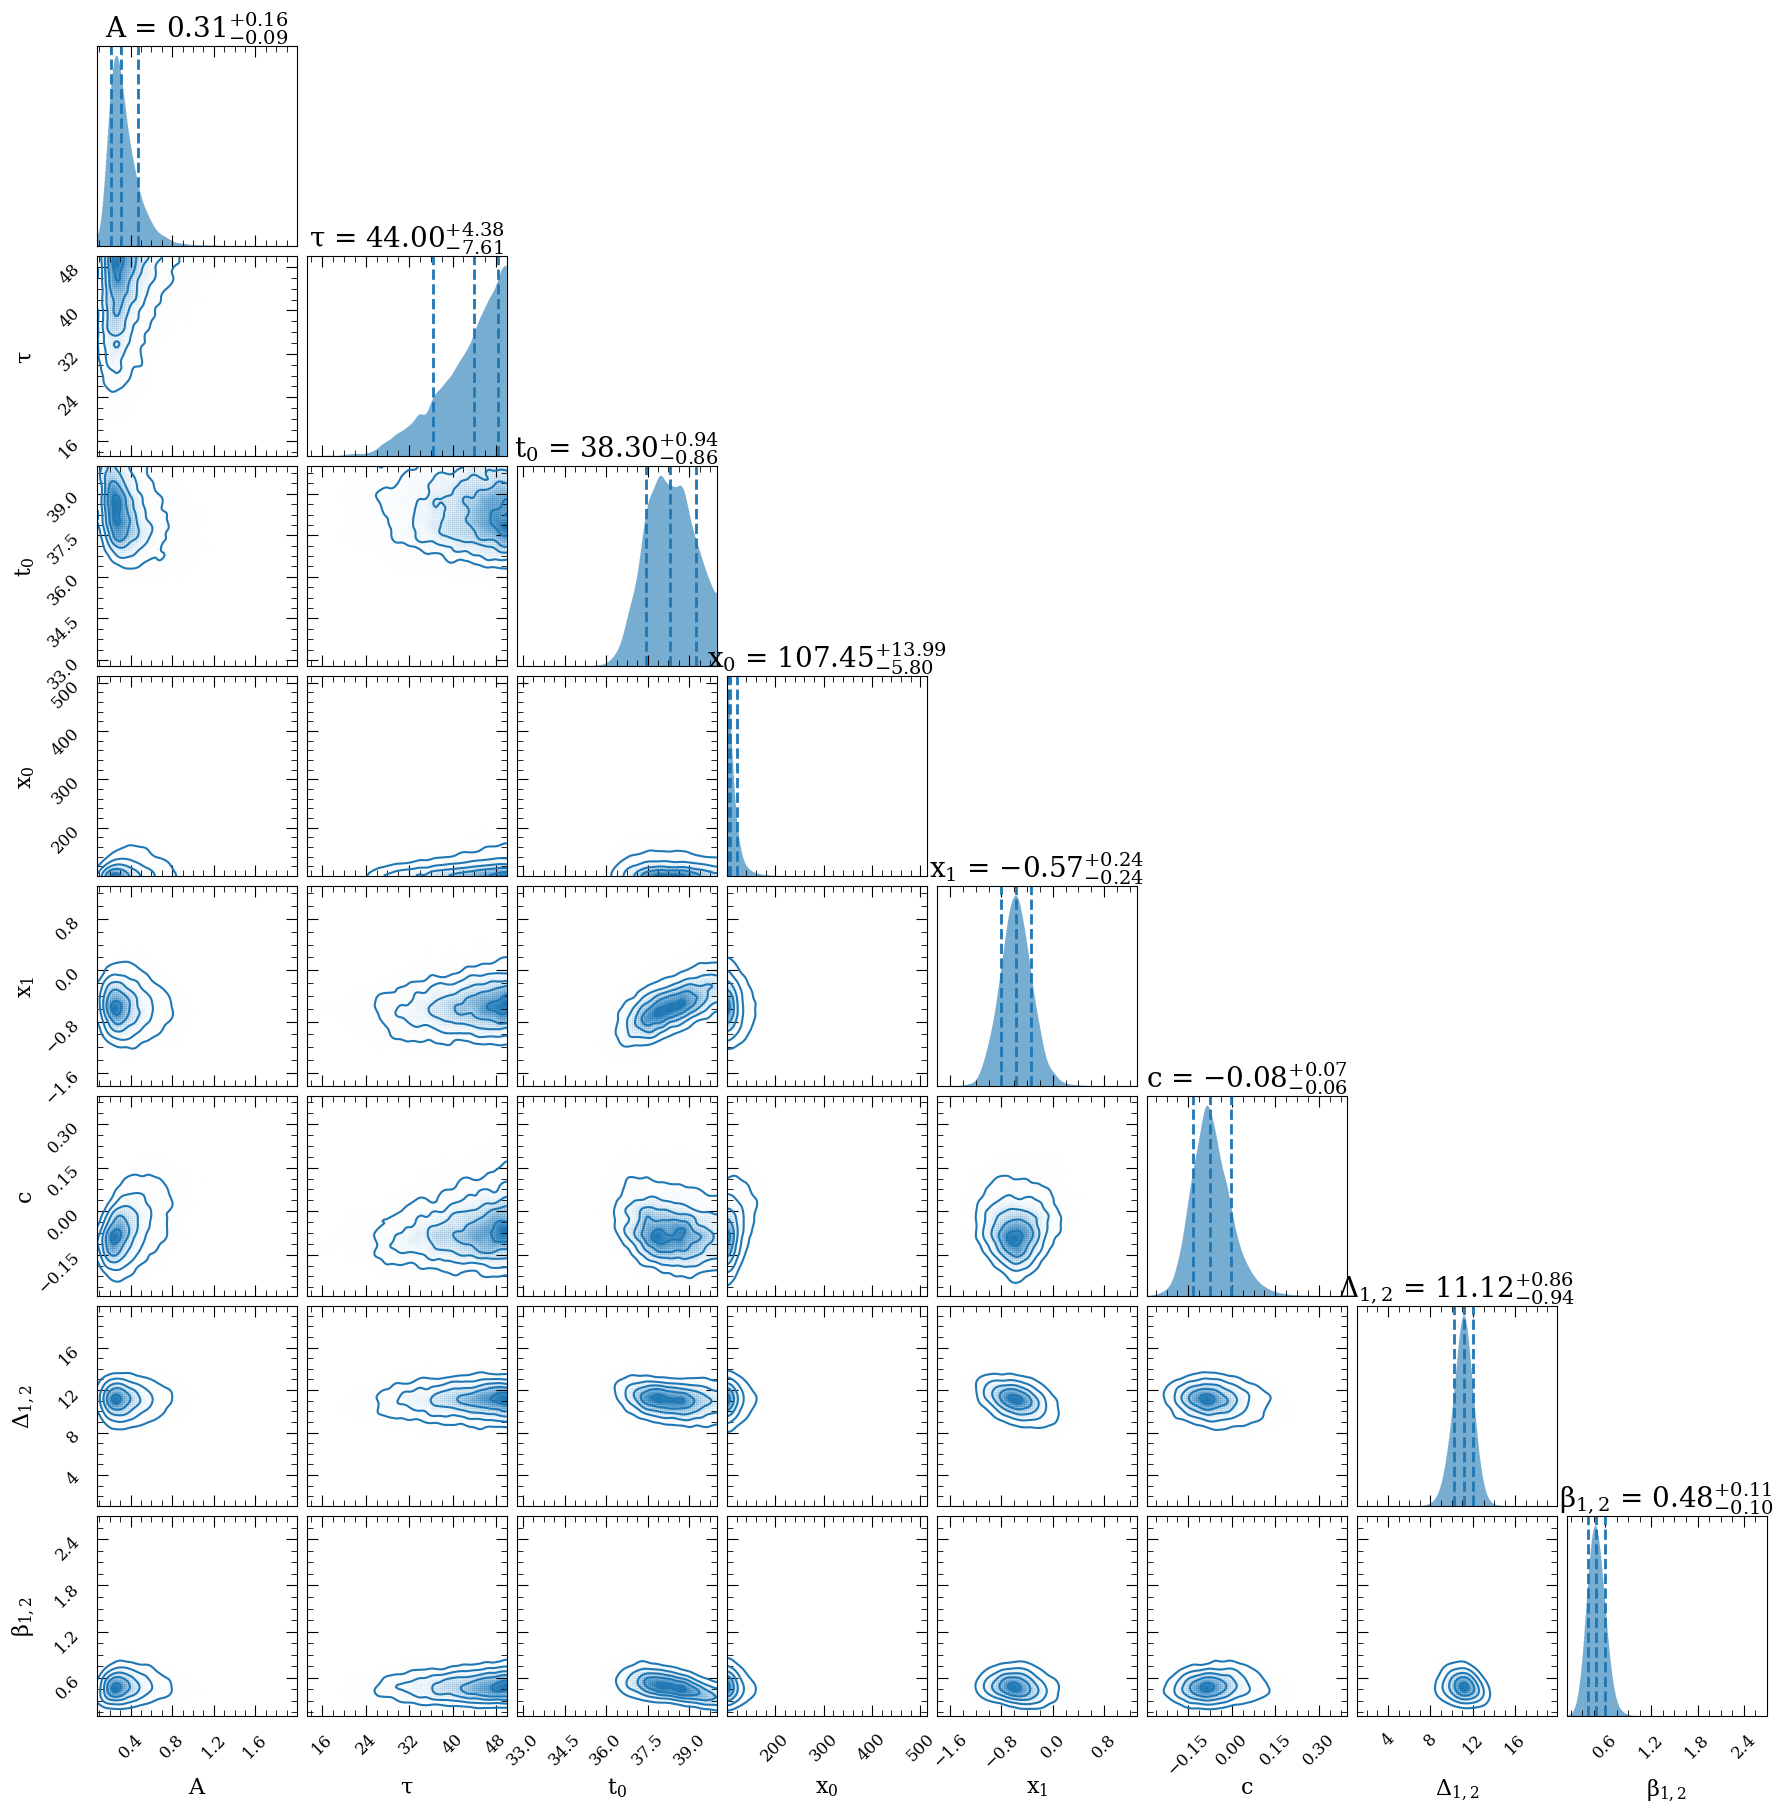

<Figure size 640x480 with 0 Axes>

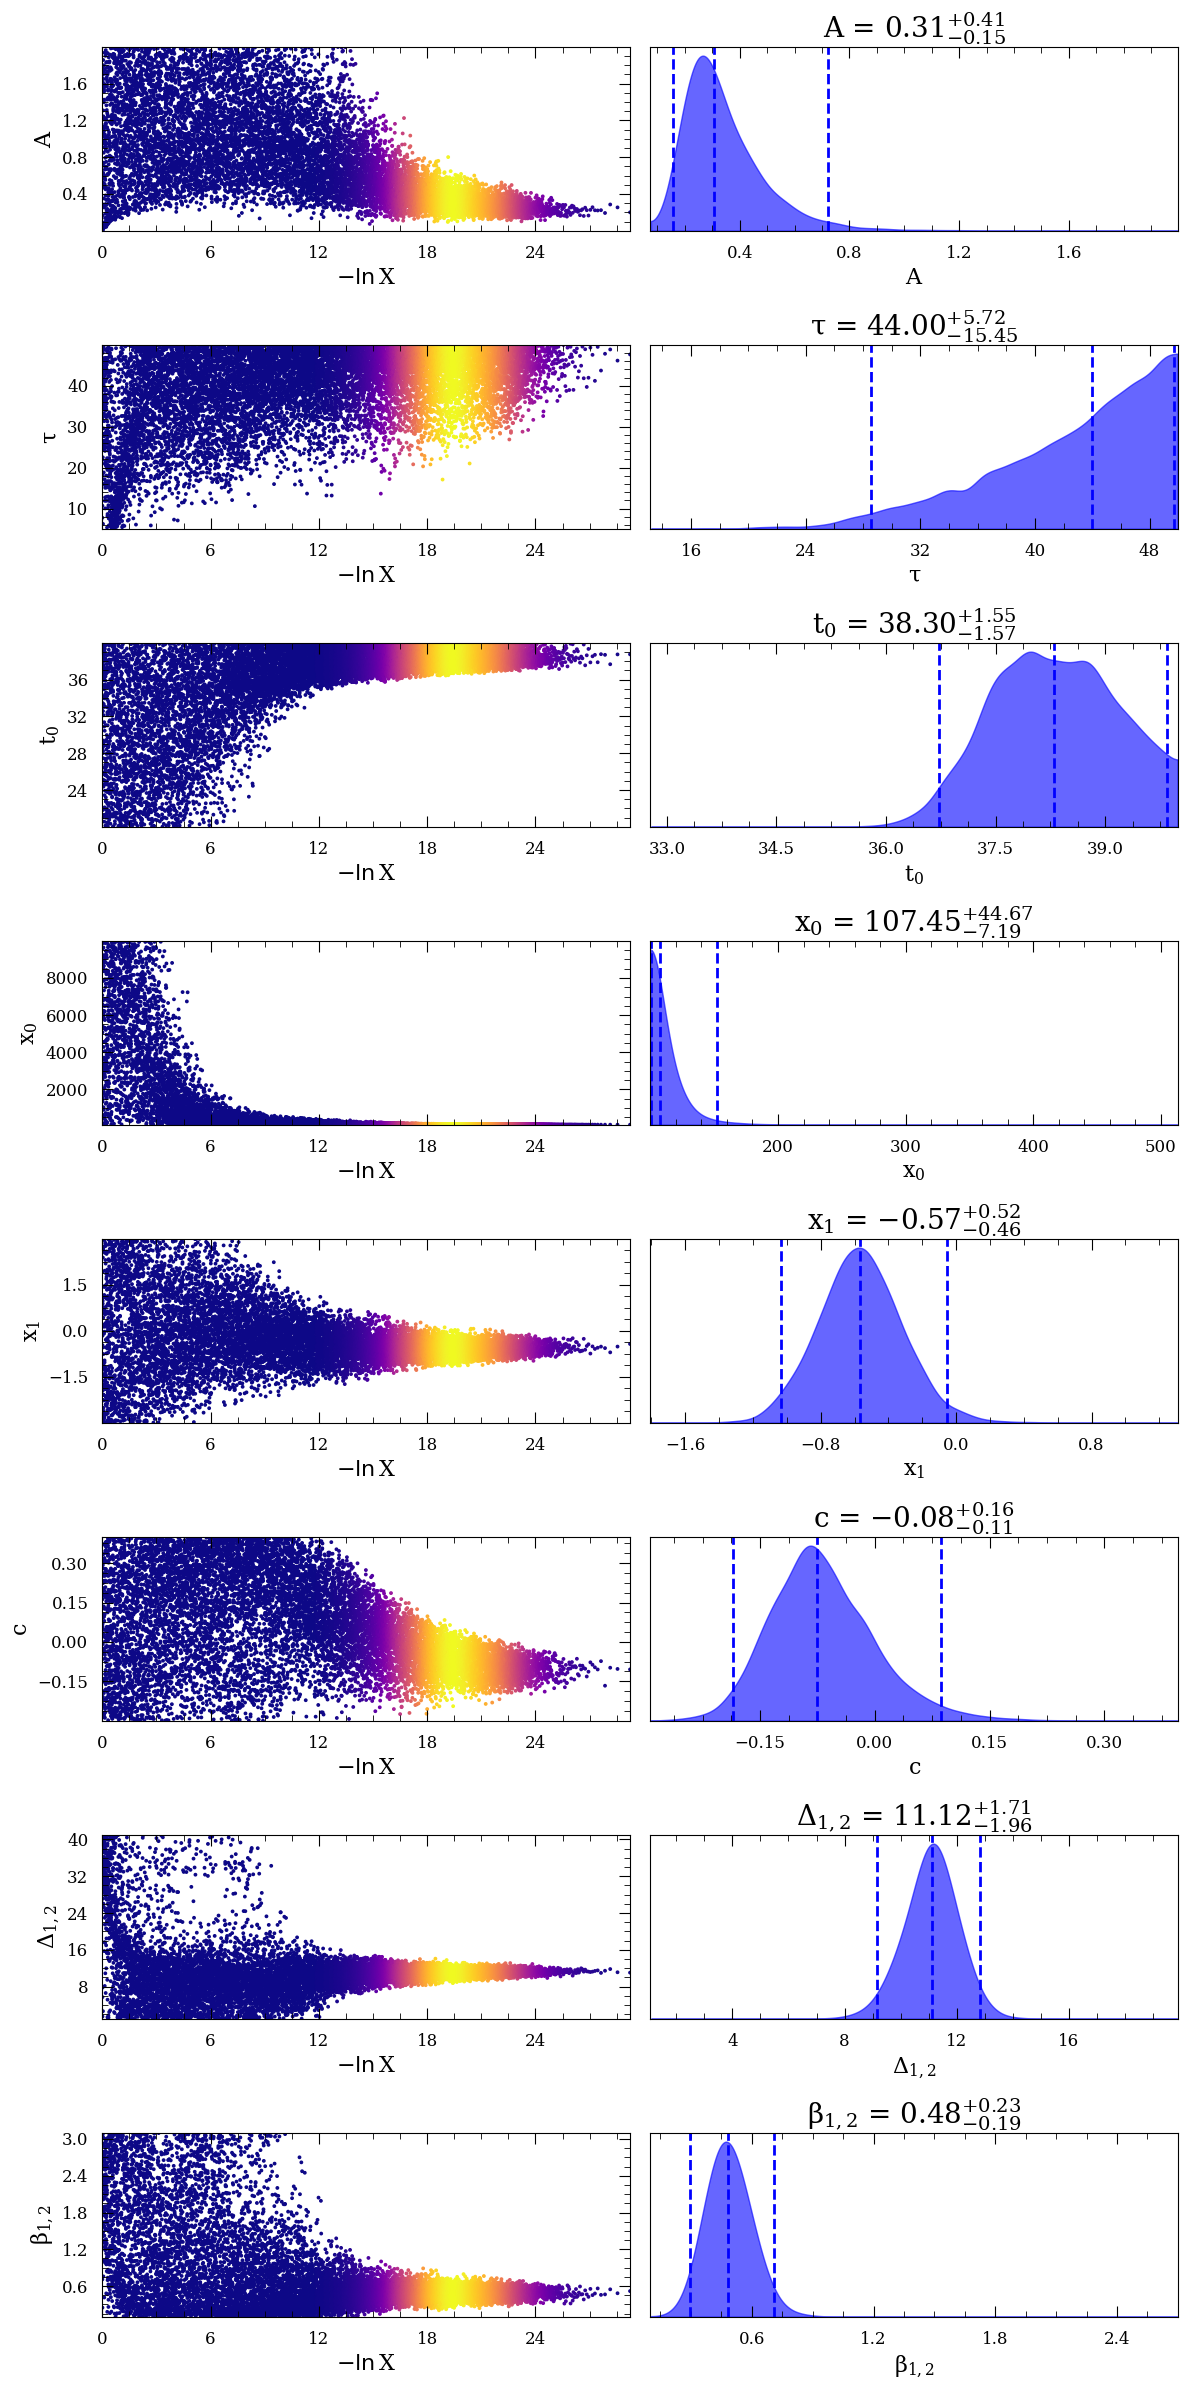

In [4]:
## Load in scarlet2 fluxes
img_indecies = [157804, 64783]


for img_index in img_indecies:
    for version in ['_v7', '_v8']:
    # img_index = 157804 #62425 #1125   #72358   #17462  #96679
        # version = '_v6'
        if img_index == 50421 or img_index==  170330 or img_index == 2737:
            additional_path = 'different_separations/large_sep/'
        elif img_index == 157804 or img_index==  64783 or img_index == 111827:
            additional_path = 'different_separations/mid_sep/'
        elif img_index == 209546 or img_index== 216276 or img_index == 62425:
            additional_path = 'different_separations/small_sep/'
        
        if version == '_v6':
            folder = 'roman_both_epoch/'
        elif version == '_v7':
            folder = 'roman_off_epoch/'
        elif version == '_v8':
            folder = 'roman_no_epoch/'
        
        scarlet_date = '14_04_26'  #used for saving images
        oversamplefactor = 1
        
        save_path = f'{additional_path}{img_index}_results/{scarlet_date}/{folder}gaussn/'
        
        
        sc_times = np.array([0, 10, 20, 30, 36, 40, 44, 48, 50, 56, 60, 70, 80, 100, 130, 140])
        
        f = h5py.File('lsst-altsched-1a-lowz.h5','r')
        simitems = np.asarray(f['system']['block0_items'][()],dtype=str)
        simdataall = f['system']['block0_values'][()]
        simdata=simdataall[img_index]
        z_source = simdata[simitems == "zs"][0]
        if z_source > 0.915:
                z_source = 0.915
        
        # --- Load  Scarlet flux pickle file ---
        with open('fluxes_files/scarlet_deblended_flux/rubin_scarlet_caustics_fluxes_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
            flux_data = pickle.load(f)  # shape: [bands, epochs, images]
        # --- Load  Scarlet flux errors pickle file ---
        with open('fluxes_files/scarlet_deblended_flux_errors/rubin_scarlet_caustics_errors_'+str(img_index)+str(version)+'.pkl', 'rb') as f:
            variance_data = pickle.load(f)  # shape: [bands, epochs, images]
        
        
        rubin_bands = ['lsstg', 'lsstr', 'lssti']
        rubin_params = {'read_noise': 10.0,
                'pixel_scale': 0.2, 
                'ccd_gain': 2.3,
                'exposure_time': {'lsstg': 15.0, 'lsstr': 15.0, 'lssti': 15.0},
                'sky_brightness_mags': {'lsstg': 22.26, 'lsstr': 21.2, 'lssti': 20.48},
                'zero_points_mags': {'lsstg': 28.30, 'lsstr': 28.13, 'lssti': 27.79},
                'num_exposures': {'lsstg': 200, 'lsstr': 460, 'lssti': 460},
                'seeing': {'lsstg':0.77, 'lsstr':0.73, 'lssti':0.71}
            }
        
        ## --- Reformat to GaussSN style table --- ###
        rows = []
        for b_idx, band in enumerate(rubin_bands):                    # loop over bands (g, r, i)
            # if b_idx != 0:
            for epoch_idx, (epoch_fluxes, epoch_variances) in enumerate(zip(flux_data[b_idx], variance_data[b_idx])): # loop over epochs
                # for image_idx, (flux, variance) in enumerate(zip(epoch_fluxes, epoch_variances)):          # loop over image multiplicities
                total_flux = np.sum(epoch_fluxes)
                total_variance = np.sum(epoch_variances)
                rows.append({
                        'band': band,
                        'image': 'unresolved',     #GausSN uses 1, 2, 3... (and not 0, 1, 2...)
                        'time': sc_times[epoch_idx],
                        'flux': total_flux,
                        'fluxerr': total_variance,
                        'zp': rubin_params['zero_points_mags'][band],
                        'zpsys': 'AB'
                    })
        data = Table(rows)
        data.sort(['band', 'image', 'time'])
        
        ## ---  Convert image index --> string labels so utils.plot_object() doesn’t crash --- ###
        # data['image'] = [f"image_{i}" for i in data['image']]
        
        ## --- Make all errors constant per band --- ####
        median_errs = {}
        for band in np.unique(data['band']):
            # mask for this band, and nonzero flux values
            mask = (data['band'] == band) & (data['flux'] != 0)
            # compute median only for those points
            if np.any(mask):
                median_errs[band] = np.median(data['fluxerr'][mask])
            else:
                median_errs[band] = np.nan  # handle case if all fluxes are 0
            print(f"{band}: median fluxerr (excluding flux=0) = {median_errs[band]}")
        # Replace all errors with that constant per band
        for band in np.unique(data['band']):
            mask = data['band'] == band
            data['fluxerr'][mask] = median_errs[band]
        
        
        # Normalize fluxes
        factor = np.max(data['flux']) - np.min(data['flux'])
        data['flux'] = data['flux'] / factor
        data['fluxerr'] = data['fluxerr'] / factor
        
        # Normalize times so that the first epoch is 0
        data['time'] = data['time'] - np.min(data['time'])
        
        print(data)  
        
        
        fig, ax = utils.plot_object(data)
        plt.show()
        
        
        
        def ptform(u):
            prior = u
            prior[0] = (u[0] * 2)                 # A          --> make prior 0 to 0.2
            prior[1] = (u[1] * 45) + 5            # tau        --> make prior 5 to 50
            prior[2] = (u[2] * 20) + 20           # t0         --> make prior 10 to 70    --> true is 50 unlensed, first imaeg at 30ish tho
            prior[3] = (u[3] * 9900) + 100        # x0/e-9     --> make prior 1e-7 to e-6    --> true is ?? approximately 1??
            prior[4] = (u[4] * 6) - 3             # x1         --> make prior -3 to 3     --> true is 0.1
            prior[5] = (u[5] * 0.7) - 0.3         # c          --> make prior -0.3 to 0.3 --> true is -0.1
            prior[6] = (u[6] * 40) + 1            # delta_1,2  --> make prior 1 to 41     --> true is 19
            prior[7] = (u[7] * 3) + 0.1                 # beta_1,2   --> make prior 0.1 to 2   
            return(prior)
        
        def fit_lensedSN(data, show_plots=False, save_plots = True):
        
            def _make_mask_unresolved(self, bands, images):
                mask = np.zeros((len(bands), len(bands)))
                for i in range(len(bands)):
                    for j in range(len(bands)):
                        if bands[i] == bands[j]:
                            mask[i, j] = 1
                return mask
        
            # Define a GP with a kernel and SALT mean function
            model = sncosmo.Model(source='salt2')
            model.set(z=z_source, t0=50, x0=1, x1=0., c=0.)
        
            kernel = kernels.ExpSquaredKernel([0.5, 20])
            meanfunc = meanfuncs.sncosmoMean(model=model, fixed=[True, False, False, False, False])
            lensingmodel = lensingmodels.ConstantMagnification([0, 1])
            lensingmodel.make_mask = lambda bands, images: _make_mask_unresolved(lensingmodel, bands, images)
            gp = gausSN.GP(kernel, meanfunc, lensingmodel)
            # gp.n_images = 2
                
            sampler = gp.optimize_parameters(x = data['time'], y = data['flux'], yerr = data['fluxerr'], band = data['band'], image = data['image'],
                                             method='dynesty', ptform=ptform, sampler_kwargs = {'sample': 'rslice'}, n_images = 2)
            
            # If desired, plot the results of the parameter optimization
            if show_plots:
                plt.figure()
                param_names = ['$A$', '$\\tau$', '$t_{0}$', '$x_{0}$', '$x_{1}$', '$c$', '$\\Delta_{1,2}$', '$\\beta_{1,2}$']
                fig, ax = utils.make_corner(sampler.results, param_names)
                fig.show()
                if save_plots:
                    fig.savefig(f"{save_path}{img_index}_glimpse_unresolved_fit1{version}.png", bbox_inches='tight')
                fig.show()
                
                fig, ax = utils.make_traceplot(sampler.results, param_names)
                if save_plots:
                    fig.savefig(f"{save_path}{img_index}_glipmse_unresolved_fit2{version}.png", bbox_inches='tight')
                fig.show()
            
            return sampler
        
        
        
        sampler = fit_lensedSN(data, show_plots=True, save_plots = True)

### Plot the fitted light curve

/home/vk9342/GausSN/gaussn/utils.py:289: RuntimeWarning: invalid value encountered in divide
  y = image['flux'] / np.multiply(gp.lensingmodel.betas[m], template)
/home/vk9342/GausSN/gaussn/utils.py:290: RuntimeWarning: divide by zero encountered in divide
  yerr = image['fluxerr'] / np.multiply(gp.lensingmodel.betas[m], template)


LinAlgError: SVD did not converge

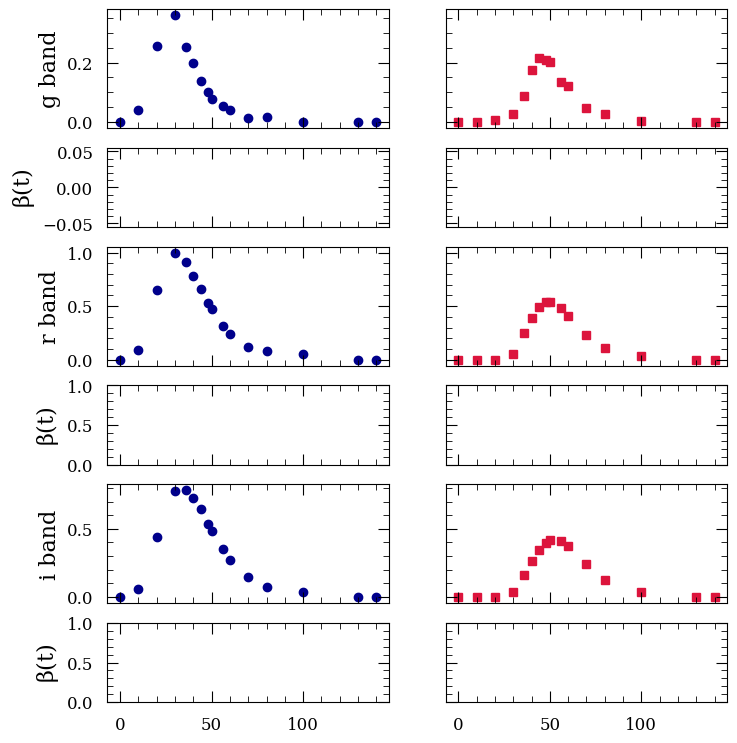

In [24]:
model = sncosmo.Model(source='salt2')
model.set(z=z_source, t0=50, x0=1, x1=0., c=0.)

kernel = kernels.ExpSquaredKernel([0.5, 20])
meanfunc = meanfuncs.sncosmoMean(model=model, fixed=[True, False, False, False, False])
lensingmodel = lensingmodels.ConstantMagnification([0, 1])

fig, ax = utils.plot_fitted_object(data, sampler.results, kernel, meanfunc, lensingmodel)

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import sncosmo

from gaussn import gausSN, kernels, meanfuncs, lensingmodels, utils

def plot_fitted_object(data, factor, results, kernel, meanfunc, lensingmodel, fix_kernel_params=False, fix_mean_params=False, fix_lensing_params=False,
                       predict_times = np.linspace(0, 150, 100), N_iter=10, n_images=None,
                       color_dict_data = {'image_1': 'darkblue', 'image_2': 'crimson', 'image_3': 'darkgreen', 'image_4': 'tab:orange', 'unresolved': 'k'},
                       color_dict_fit = {'image_1': 'tab:blue', 'image_2': 'palevioletred', 'image_3': 'tab:green', 'image_4': 'darkorange', 'unresolved': 'dimgray'},
                       marker_dict={'image_1': 's', 'image_2': 'D', 'image_3': '>', 'image_4': '<', 'unresolved': 'o'}, title=''):
    """
    Plots the fitted glSN with uncertainties, assuming the GausSN2 model.

    Args:
        data (Table): Data containing flux measurements.
        results (obj): Results of the fitting.
        kernel (obj): Kernel object.
        meanfunc (obj): Mean function object.
        lensingmodel (obj): Lensing model object.
        fix_kernel_params (bool): If True, fixes kernel parameters.
        fix_mean_params (bool): If True, fixes mean function parameters.
        fix_lensing_params (bool): If True, fixes lensing model parameters.
        color_dict_data (dict): Dictionary mapping image number (i.e. 'image_1') to colors for plotting data.
        color_dict_fit (dict): Dictionary mapping image number (i.e. 'image_1') to colors for plotting fitted light curves.
        title (str): Title of the plot.

    Returns:
        tuple: The figure and axis of the plot.
    """

    # Array specifying the order of bands
    unresolved_bands = utils.ordered[np.isin(utils.ordered, np.unique(data[data['image'] == 'unresolved']['band']))]
    resolved_bands = utils.ordered[np.isin(utils.ordered, np.unique(data[data['image'] != 'unresolved']['band']))]
    image_num_labels = np.unique(data[data['image'] != 'unresolved']['image'])
    if n_images is None:
        n_images = len(image_num_labels)

    # Create subplots based on the number of unique bands
    fig, ax = plt.subplots(2*len(np.unique(data['band'])), n_images, figsize=(8, 1.5 * ( 2 * (len(unresolved_bands) + len(resolved_bands)) ) ),
                           sharex=True, sharey='row', gridspec_kw={'height_ratios': np.tile([3, 2], len(np.unique(data['band'])))})

    Plot flux measurements for each band and image
    for b, pb_id in enumerate(list(unresolved_bands)):
        band = data[data['band'] == pb_id]

        try:
            color_dict_data_temp = color_dict_data[pb_id]
        except:
            color_dict_data_temp = color_dict_data

        try:
            marker_dict_temp = marker_dict[pb_id]
        except:
            marker_dict_temp = marker_dict

        try:
            color = color_dict_data_temp['unresolved']
        except:
            color = color_dict_data_temp

        try:
            marker = marker_dict_temp['unresolved']
        except:
            marker = marker_dict_temp

        image_label = 'Unresolved'
        ax[b*2,0].errorbar(band['time'], band['flux'], yerr=band['fluxerr'], ls='None', marker=marker,
                           color=color, label=image_label, zorder=1)
        ax[b*2,0].invert_yaxis()
        ax[(b*2)+1,0].invert_yaxis()

    for b, pb_id in enumerate(list(resolved_bands)):
        band = data[data['band'] == pb_id]

        try:
            color_dict_data_temp = color_dict_data[pb_id]
        except:
            color_dict_data_temp = color_dict_data

        try:
            marker_dict_temp = marker_dict[pb_id]
        except:
            marker_dict_temp = marker_dict

        for m,im_id in enumerate(np.unique(data[data['image'] != 'unresolved']['image'])):
            image = band[band['image'] == im_id]

            try:
                color = color_dict_data_temp[im_id]
            except:
                color = color_dict_data_temp

            try:
                marker = marker_dict_temp[im_id]
            except:
                marker = marker_dict_temp

            image_label = 'Image '+im_id[-1]
            ax[(b+len(unresolved_bands))*2,m].errorbar(image['time'], image['flux'], yerr=image['fluxerr'], ls='None', marker=marker,
                                                       color=color, label=image_label, zorder=1)
        
        ax[(b+len(unresolved_bands))*2,0].set_ylabel(pb_id, fontsize=16)
        ax[((b+len(unresolved_bands))*2)+1,0].set_ylabel('$\\beta(t)$', fontsize=16)

        ax[(b+len(unresolved_bands))*2,0].invert_yaxis()
        ax[((b+len(unresolved_bands))*2)+1,0].invert_yaxis()

    # Get equal-weighted samples from the results
    samples = results.samples_equal()

    # Iterate over random samples from the posterior
    for iter in np.random.choice(len(samples), N_iter):
        sample = samples[iter]

        # Reset parameters based on whether they are fixed
        if not fix_lensing_params and not fix_mean_params and not fix_kernel_params:
            kernel_params = [sample[i] for i in range(len(kernel.params))]
            meanfunc_params = [sample[i+len(kernel.params)] for i in range(len(meanfunc.params))]
            lensing_params = [sample[i+len(kernel.params)+len(meanfunc.params)] for i in range(len(lensingmodel.params))]
            kernel._reset(kernel_params)
            #meanfunc._reset(meanfunc_params)
            lensingmodel._reset(lensing_params)
        elif not fix_mean_params and not fix_kernel_params:
            kernel_params = [sample[i] for i in range(len(kernel.params))]
            meanfunc_params = [sample[i+len(kernel.params)] for i in range(len(meanfunc.params))]
            kernel._reset(kernel_params)
            #meanfunc._reset(meanfunc_params)
        elif not fix_mean_params and not fix_lensing_params:
            meanfunc_params = [sample[i] for i in range(len(meanfunc.params))]
            lensing_params = [sample[i+len(meanfunc.params)] for i in range(len(lensingmodel.params))]
            #meanfunc._reset(meanfunc_params)
            lensingmodel._reset(lensing_params)
        elif not fix_kernel_params and not fix_lensing_params:
            kernel_params = [sample[i] for i in range(len(kernel.params))]
            lensing_params = [sample[i+len(kernel.params)] for i in range(len(lensingmodel.params))]
            kernel._reset(kernel_params)
            lensingmodel._reset(lensing_params)
        elif not fix_kernel_params:
            kernel_params = [sample[i] for i in range(len(kernel.params))]
            kernel._reset(kernel_params)
        elif not fix_mean_params:
            meanfunc_params = [sample[i] for i in range(len(meanfunc.params))]
            #meanfunc._reset(meanfunc_params)
        elif not fix_lensing_params:
            lensing_params = [sample[i] for i in range(len(lensingmodel.params))]
            lensingmodel._reset(lensing_params)
        
        # Create GP object
        gp = gausSN.GP(kernel, meanfunc, lensingmodel)

        for b, pb_id in enumerate(unresolved_bands):
            band = data[data['band'] == pb_id]
            eff_wave = [sncosmo.get_bandpass(b).wave_eff for b in band['band']]

            if len(band) < 1:
                continue

            try:
                color_dict_fit_temp = color_dict_fit[pb_id]
            except:
                color_dict_fit_temp = color_dict_fit

            repeated_times = np.tile(band['time'], n_images)
            repeated_deltas = np.repeat(gp.lensingmodel.deltas, len(band))
            repeated_betas = np.repeat(gp.lensingmodel.betas, len(band))
            for m in range(n_images):
                if m == 0:
                    T = np.diag(repeated_betas[m * len(band) : (m+1) * len(band)])
                else:
                    T = np.hstack([T, np.diag(repeated_betas[m * len(band) : (m+1) * len(band)])])

            x = np.subtract(repeated_times, repeated_deltas)
            template = gp.meanfunc.mean(x, bands=np.repeat(band['band'], n_images), images=np.repeat(image_num_labels, len(band)),
                                        zp=np.repeat(band['zp'], n_images), zpsys=np.repeat(band['zpsys'], n_images), params=meanfunc_params)
            y = band['flux'] / np.matmul(T, template)
            yerr = band['fluxerr'] / np.matmul(T, template)

            repeated_predict_times = np.tile(predict_times, n_images)
            repeated_predict_deltas = np.repeat(gp.lensingmodel.deltas, len(predict_times))
            repeated_predict_betas = np.repeat(gp.lensingmodel.betas, len(predict_times))
            for m in range(n_images):
                if m == 0:
                    predict_T = np.diag(repeated_predict_betas[m * len(predict_times) : (m+1) * len(predict_times)])
                else:
                    predict_T = np.hstack([predict_T, np.diag(repeated_predict_betas[m * len(predict_times) : (m+1) * len(predict_times)])])

            predict_x = np.subtract(repeated_predict_times, repeated_predict_deltas)
            template_predict = np.matmul(predict_T, gp.meanfunc.mean(predict_x, bands=np.repeat(pb_id, len(predict_x)),
                                                                     images=np.repeat(image_num_labels, len(predict_times)),
                                                                     zp=np.repeat(band['zp'][0], len(predict_x)),
                                                                     zpsys=np.repeat(band['zpsys'][0], len(predict_x)), params=meanfunc_params))

            predict_wave = np.repeat(sncosmo.get_bandpass(pb_id).wave_eff, len(predict_times))

            mu_U = np.repeat(1., len(predict_times))
            mu_V = np.repeat(1., len(band))

            cov_UU = gp.kernel.covariance(np.vstack([predict_times, predict_wave]), params=kernel_params)
            cov_UV = gp.kernel.covariance(np.vstack([predict_times, predict_wave]), x_prime=np.vstack([band['time'], eff_wave]), params=kernel_params)
            cov_VV = gp.kernel.covariance(np.vstack([band['time'], eff_wave]), params=kernel_params) + np.diagflat(yerr**2)

            exp = mu_U + (cov_UV @ np.linalg.solve(cov_VV, y-mu_V))
            cov = cov_UU - (cov_UV @ np.linalg.solve(cov_VV, np.transpose(cov_UV)))

            for i in range(1):
                beta_realization = np.random.multivariate_normal(mean=exp, cov=cov, size=1)
                    
                try:
                    color = color_dict_fit_temp['unresolved']
                except:
                    color = color_dict_fit_temp
                
                fluxes = beta_realization[0]*factor*template_predict
                mags = band['zp'][0] - 2.5 * np.log10( fluxes )
                ax[b*2,0].plot(predict_times, mags, color=color, alpha=0.2, zorder=2)
                ax[(b*2)+1,0].plot(predict_times, -2.5*np.log10(beta_realization[0]), color=color, alpha=0.2)


        for m, im_id in enumerate(image_num_labels):
            image = data[data['image'] == im_id]
            ax[0,m].set_title(f'Image {m+1}', fontsize=16)
            ax[-1,m].set_xlabel('Time [days]', fontsize=16)

            if len(image) < 1:
                continue

            x = np.subtract(image['time'], gp.lensingmodel.deltas[m])
            mask = np.logical_and(x > gp.meanfunc.model.mintime(), x < gp.meanfunc.model.maxtime())
            y = np.array([sncosmo.get_bandpass(b).wave_eff for b in image['band']])
            template = gp.meanfunc.mean(x[mask], bands=image['band'][mask], images=image['image'][mask], zp=image['zp'][mask], zpsys=image['zpsys'][mask], params=meanfunc_params)
            z = image['flux'][mask] / np.multiply(gp.lensingmodel.betas[m], template)
            zerr = image['fluxerr'][mask] / np.multiply(gp.lensingmodel.betas[m], template)

            for b, pb_id in enumerate(resolved_bands):
                band = image[image['band'] == pb_id]

                if len(band) < 1:
                    continue

                predict_x = np.subtract(predict_times, gp.lensingmodel.deltas[m])
                predict_y = np.repeat(sncosmo.get_bandpass(pb_id).wave_eff, len(predict_x))

                template_predict = np.multiply(gp.lensingmodel.betas[m], gp.meanfunc.mean(predict_x, bands=np.repeat(pb_id, len(predict_x)),
                                                                                          images=np.repeat(im_id, len(predict_x)),
                                                                                          zp=np.repeat(band['zp'][0], len(predict_x)),
                                                                                          zpsys=np.repeat(band['zpsys'][0], len(predict_x)),
                                                                                          params=meanfunc_params))

                mu_U = np.repeat(1., len(predict_x))
                mu_V = np.repeat(1., len(image))

                cov_UU = gp.kernel.covariance(np.vstack([predict_x, predict_y]), params=kernel_params)
                cov_UV = gp.kernel.covariance(np.vstack([predict_x, predict_y]), x_prime=np.vstack([x[mask], y[mask]]), params=kernel_params)
                cov_VV = gp.kernel.covariance(np.vstack([x[mask], y[mask]]), params=kernel_params) + np.diagflat(zerr**2)

                exp = mu_U + (cov_UV @ np.linalg.solve(cov_VV, z-mu_V))
                cov = cov_UU - (cov_UV @ np.linalg.solve(cov_VV, np.transpose(cov_UV)))

                for i in range(1):
                    beta_realization = np.random.multivariate_normal(mean=exp, cov=cov, size=1)
                    
                    try:
                        color = color_dict_fit[im_id][pb_id]
                    except:
                        try:
                            color = color_dict_fit[pb_id]
                        except:
                            try:
                                color = color_dict_fit[im_id]
                            except:
                                color = color_dict_fit

                    fluxes = beta_realization[0]*factor*template_predict
                    # mags = band['zp'][0]-2.5*np.log10(fluxes)
                    ax[(b+len(unresolved_bands))*2,m].plot(predict_times, fluxes, color=color, alpha=0.2, zorder=2)
                    ax[((b+len(unresolved_bands))*2)+1,m].plot(predict_times, -2.5*np.log10(beta_realization[0]), color=color, alpha=0.2)

    # Set title, ylabel for the flux and adjust subplot spacing
    fig.supylabel('Flux', fontsize=20)
    fig.suptitle(title, fontsize=24)
    fig.tight_layout()
    fig.subplots_adjust(hspace=0)
    return fig, ax

TypeError: sub got incompatible shapes for broadcasting: (2, 1, 100), (1, 2, 42).

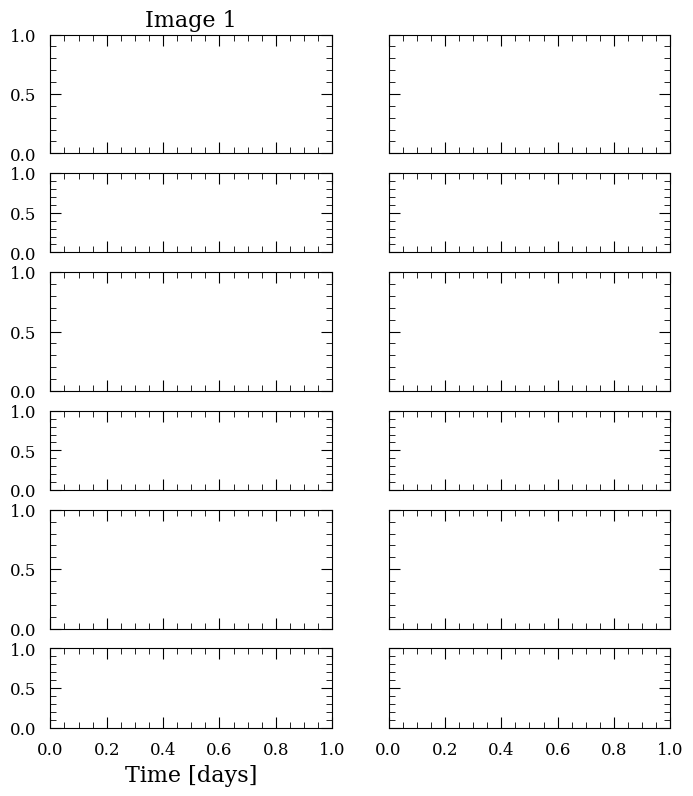

In [55]:
scaling_factor = 1e-9 

# Calculate mag and magerr
data['mag'] = data['zp'] - 2.5 * np.log10(np.maximum(data['flux'], 1e-5))
data['magerr'] = 1.0857 * (data['fluxerr'] / np.maximum(data['flux'], 1e-5))
data['magerr'] = np.clip(data['magerr'], 0, 1.0)

# Run the plot
fig, ax = plot_fitted_object(
    data = data, 
    factor = scaling_factor, 
    results = sampler.results, 
    kernel = kernel, 
    meanfunc = meanfunc, 
    lensingmodel = lensingmodel,
    N_iter = 15,
    predict_times = np.linspace(20, 120, 100), # Your range
    title = 'GausSN Fit: Rubin + Roman Data'
)
plt.show()